# First plotting

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import FuncFormatter, MaxNLocator
import seaborn as sns

file_path = 'ToleranceTest_MasterDoc.xlsx'

df = pd.read_excel(file_path, engine='openpyxl')

print(df.head())
print(df.columns.tolist())

  Test_ID       Date Species  Altitude      Time BF_Distance  \
0    AJ01 2024-11-07    Lion        60  10:33:00          38   
1    AJ02 2024-11-07    Lion       100  11:35:00          35   
2    AJ03 2024-11-07    Lion        40  11:50:00          35   
3    AJ04 2024-11-08    Lion       120  17:15:00          18   
4    AJ05 2024-11-08    Lion       100  17:47:00          14   

   BF_Distance_averaged BF_Agonistic BF_Aggressive/Flee BF_Fear  ...  \
0                    38            N                  N       N  ...   
1                    35            N                  N       N  ...   
2                    35            N                  N       N  ...   
3                    18          NaN                  N       N  ...   
4                    14          NaN                  N       N  ...   

  Drone_N_M Drone_N_c DroneVIDEO_N_Individual DroneVIDEO_N_F DroneVIDEO_N_M  \
0         2         3                       6              1              2   
1         2         3   

## Lions data preparation

In [2]:
# data preparation 


data = df[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Agonistic', 'BF_Aggressive/Flee', 'BF_Fear', 'BF_Stereotypic', 
'BF_Vocalization', 'BF_Active/Exploratory', 'BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Affiliative_Reproductive', 
'BF_Loc', 'BF_Calm', 'BF_Inactive', 'AF_Agonistic', 'AF_Aggressive/Flee', 'AF_Fear', 'AF_Stereotypic', 'AF_Vocalization', 
'AF_Active/Exploratory', 'AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 
'AF_Calm', 'AF_Inactive', 'Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'prides']]

data = data.rename(columns={'BF_Aggressive/Flee': 'BF_Flee'})  
data = data.rename(columns={'AF_Aggressive/Flee': 'AF_Flee'})  
data = data.rename(columns={'BF_Active/Exploratory': 'BF_Exploratory'})  
data = data.rename(columns={'AF_Active/Exploratory': 'AF_Exploratory'})  
data = data[data['Species'] == 'Lion']


# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract the week number and create a new 'Week' column
data['Week'] = data['Date'].dt.isocalendar().week

# Display the resulting DataFrame with the new 'Week' column
print(data[['Date', 'Week']])

columns_to_transform = [
    'BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic', 
    'BF_Vocalization', 'BF_Exploratory', 'BF_Marking', 'BF_Maintenance', 
    'BF_Feeding', 'BF_Affiliative_Reproductive', 'BF_Loc', 'BF_Calm', 
    'BF_Inactive', 'AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic', 
    'AF_Vocalization', 'AF_Exploratory', 'AF_Marking', 'AF_Maintenance', 
    'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 'AF_Calm', 
    'AF_Inactive',  'Kill', 'Pride_with_cubs'
]

# Transform the values
data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))

# Combine columns as specified
data['BF_Flee/Fear'] = data[['BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic']].sum(axis=1)
data['BF_Feeding/Affiliative/Mating'] = data[['BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Vocalization','BF_Affiliative_Reproductive']].sum(axis=1)
data['AF_Flee/Fear'] = data[['AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic']].sum(axis=1)
data['AF_Feeding/Affiliative/Mating'] = data[['AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Vocalization', 'AF_Affiliative_Reproductive']].sum(axis=1)

# Display the resulting DataFrame
print(data[['BF_Flee/Fear', 'BF_Feeding/Affiliative/Mating', 'AF_Flee/Fear', 'AF_Feeding/Affiliative/Mating']])



         Date  Week
0  2024-11-07    45
1  2024-11-07    45
2  2024-11-07    45
3  2024-11-08    45
4  2024-11-08    45
..        ...   ...
64 2024-11-23    47
65 2024-11-25    48
66 2024-11-25    48
67 2024-11-25    48
68 2024-11-25    48

[69 rows x 2 columns]
    BF_Flee/Fear  BF_Feeding/Affiliative/Mating  AF_Flee/Fear  \
0            0.0                              0             1   
1            0.0                              0             1   
2            0.0                              0             0   
3            0.0                              0             0   
4            0.0                              0             0   
..           ...                            ...           ...   
64           0.0                              0             0   
65           0.0                              0             1   
66           0.0                              0             0   
67           0.0                              0             0   
68           0.0      

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_46907/4256653760.py:38: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))


## Behavioral states vs heights

### Flee/Fear reactions

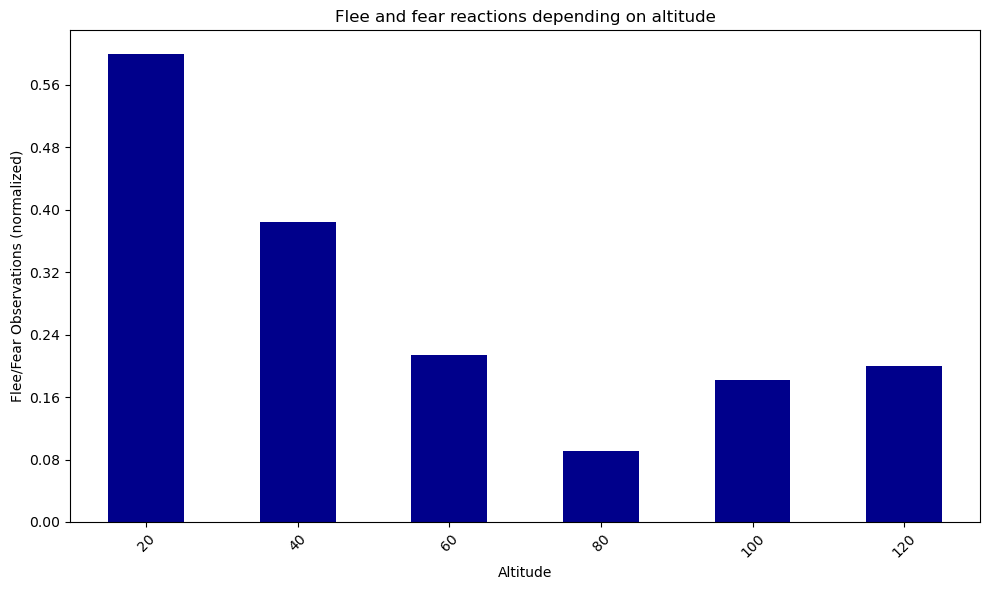

In [3]:
# Group the data by 'Altitude' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('Altitude')['AF_Flee/Fear'].sum()

observation_counts = data.groupby('Altitude').size()

normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='darkblue')

plt.title('Flee and fear reactions depending on altitude')
plt.xlabel('Altitude')
plt.ylabel('Flee/Fear Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('reactions.vs.heights.png', bbox_inches='tight')
plt.show()

In [5]:
# Calculate the total sum of 'AF_Flee/Fear' values
total_flee_fear = grouped_data.sum()

# Calculate the percentage of flee/fear reactions at each altitude
percentage_data = (grouped_data / total_flee_fear) * 100
print(percentage_data)

Altitude
20     31.578947
40     26.315789
60     15.789474
80      5.263158
100    10.526316
120    10.526316
Name: AF_Flee/Fear, dtype: float64


In [4]:
# further data preparation


data = df[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Agonistic', 'BF_Aggressive/Flee', 'BF_Fear', 'BF_Stereotypic', 
'BF_Vocalization', 'BF_Active/Exploratory', 'BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Affiliative_Reproductive', 
'BF_Loc', 'BF_Calm', 'BF_Inactive', 'AF_Agonistic', 'AF_Aggressive/Flee', 'AF_Fear', 'AF_Stereotypic', 'AF_Vocalization', 
'AF_Active/Exploratory', 'AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 
'AF_Calm', 'AF_Inactive', 'Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'prides']]

data = data.rename(columns={'BF_Aggressive/Flee': 'BF_Flee'})  
data = data.rename(columns={'AF_Aggressive/Flee': 'AF_Flee'})  
data = data.rename(columns={'BF_Active/Exploratory': 'BF_Exploratory'})  
data = data.rename(columns={'AF_Active/Exploratory': 'AF_Exploratory'})  
data = data[data['Species'] == 'Lion']

data['Pride_ID'] = data['Test_ID'].str[:2]

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract the week number and create a new 'Week' column
data['Week'] = data['Date'].dt.isocalendar().week

# Display the resulting DataFrame with the new 'Week' column
print(data[['Date', 'Week']])

columns_to_transform = [
    'BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic', 
    'BF_Vocalization', 'BF_Exploratory', 'BF_Marking', 'BF_Maintenance', 
    'BF_Feeding', 'BF_Affiliative_Reproductive', 'BF_Loc', 'BF_Calm', 
    'BF_Inactive', 'AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic', 
    'AF_Vocalization', 'AF_Exploratory', 'AF_Marking', 'AF_Maintenance', 
    'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 'AF_Calm', 
    'AF_Inactive',  'Kill', 'Pride_with_cubs'
]

# Transform the values
data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))

# Define a function to convert positive sums to 1
def convert_to_binary(value):
    return 1 if value > 0 else value

# Combine columns as specified and apply the conversion function
data['BF_Flee/Fear'] = data[['BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['BF_Calm/Inactive'] = data[['BF_Calm', 'BF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['BF_Feeding/Affiliative/Mating'] = data[['BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Vocalization', 'BF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)
data['AF_Flee/Fear'] = data[['AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['AF_Calm/Inactive'] = data[['AF_Calm', 'AF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['AF_Feeding/Affiliative/Mating'] = data[['AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Vocalization', 'AF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)

# Display the resulting DataFrame
print(data[['BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating']])

# --- Altitude Transformation ---
data['log_altitude'] = np.log(data['Altitude'])
data['z_log_altitude'] = (data['log_altitude'] - data['log_altitude'].mean()) / data['log_altitude'].std()

data = data[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 'BF_Loc', 'BF_Exploratory',
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating', 'AF_Loc', 'AF_Exploratory','Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'log_altitude', 'z_log_altitude', 'prides']]

def melt_behavior_data(data, prefix):
    behavior_columns = [
        f'{prefix}_Flee/Fear', f'{prefix}_Calm/Inactive', f'{prefix}_Feeding/Affiliative/Mating', f'{prefix}_Loc',  f'{prefix}_Exploratory'
    ]
    # Include 'Pride_with_cubs' and 'DroneVIDEO_N_c' in id_vars to retain them
    melted_data = data.melt(
        id_vars=['Test_ID', 'Date', 'Species', 'Altitude','z_log_altitude', 'Pride_with_cubs', 'DroneVIDEO_N_c', 'prides', 'AF_Flee/Fear'],
        value_vars=behavior_columns,
        var_name='behavior_type',
        value_name='behavior_count'
    )
    melted_data['before_after'] = 0 if prefix == 'BF' else 1
    melted_data['behavior_type'] = melted_data['behavior_type'].str.replace(f'{prefix}_', '')
    return melted_data[melted_data['behavior_count'] > 0]

# Melt the data for 'before' and 'after'
before_data = melt_behavior_data(data, 'BF')
after_data = melt_behavior_data(data, 'AF')

# Concatenate the melted data
transformed_data = pd.concat([before_data, after_data], ignore_index=True)

# Use z_log_altitude only for 'after' observations
transformed_data.loc[transformed_data['before_after'] == 0, 'z_log_altitude'] = np.nan
transformed_data['z_log_altitude'].fillna(0, inplace=True)

# Select relevant columns
transformed_data = transformed_data[['Test_ID', 'Date', 'Species', 'Altitude', 'before_after', 'behavior_type', 'z_log_altitude', 'Pride_with_cubs', 'DroneVIDEO_N_c', 'prides', 'AF_Flee/Fear']]

# Create a categorical column 'Cubs_presence' where:
# 0=pride has no cubs, 1=pride has cubs but they're not present during the test, 2=pride has cubs and they're present during the test

# Create the new column with priority logic
transformed_data["Cubs_presence"] = np.where(transformed_data["DroneVIDEO_N_c"] != 0, 2, transformed_data["Pride_with_cubs"])

# Delete extra columns
transformed_data = transformed_data.drop(["DroneVIDEO_N_c"], axis=1)


         Date  Week
0  2024-11-07    45
1  2024-11-07    45
2  2024-11-07    45
3  2024-11-08    45
4  2024-11-08    45
..        ...   ...
64 2024-11-23    47
65 2024-11-25    48
66 2024-11-25    48
67 2024-11-25    48
68 2024-11-25    48

[69 rows x 2 columns]
    BF_Flee/Fear  BF_Calm/Inactive  BF_Feeding/Affiliative/Mating  \
0            0.0                 1                              0   
1            0.0                 1                              0   
2            0.0                 1                              0   
3            0.0                 1                              0   
4            0.0                 1                              0   
..           ...               ...                            ...   
64           0.0                 1                              0   
65           0.0                 1                              0   
66           0.0                 1                              0   
67           0.0                 1             

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_46907/432401663.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_46907/432401663.py:89: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transformed_data['z_log_altitude'].fillna(0, inplace=True)


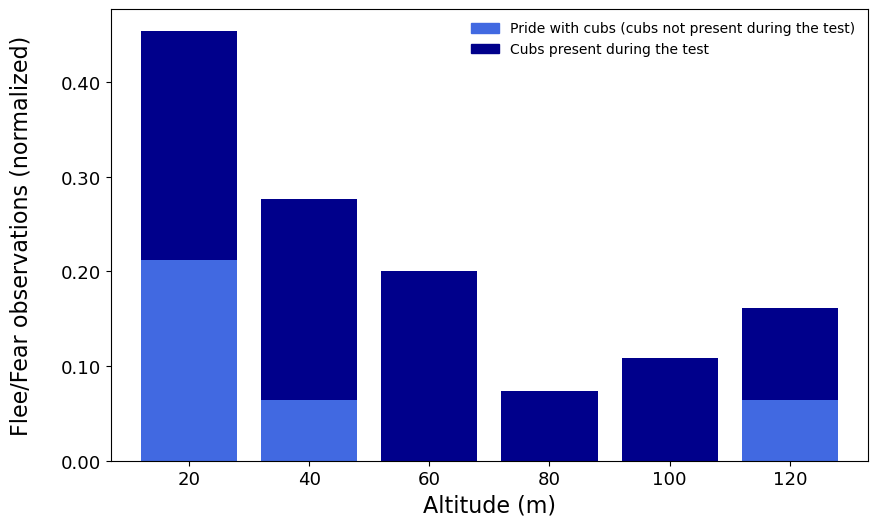

In [12]:
# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------
df = transformed_data.dropna(subset=['Altitude', 'Cubs_presence', 'AF_Flee/Fear'])

obs_per_alt = df.groupby('Altitude').size()

flee_by_alt_cubs = (
    df.groupby(['Altitude', 'Cubs_presence'])['AF_Flee/Fear']
      .sum()
      .unstack(fill_value=0)
)

cubs_order = [c for c in [0, 1, 2] if c in flee_by_alt_cubs.columns]
flee_by_alt_cubs = flee_by_alt_cubs.reindex(columns=cubs_order)

normalized = flee_by_alt_cubs.div(obs_per_alt, axis=0)

# ------------------------------------------------------------
# Styling
# ------------------------------------------------------------
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13
})

palette = {0: 'deepskyblue', 1: 'royalblue', 2: 'darkblue'}

labels = {
    0: 'Without cubs',
    1: 'Pride with cubs (cubs not present during the test)',
    2: 'Cubs present during the test'
}

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
ax = normalized.plot(
    kind='bar',
    stacked=True,
    color=[palette[c] for c in normalized.columns],
    width=0.8,
    figsize=(9, 5.5)
)

ax.set_xlabel('Altitude (m)')
ax.set_ylabel('Flee/Fear observations (normalized)', labelpad=20)  # added spacing

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f'{x:.2f}')
)

# ------------------------------------------------------------
# Clean legend (no title, remove category 0)
# ------------------------------------------------------------
keep_cols = [c for c in normalized.columns if c != 0]

handles = [plt.Rectangle((0, 0), 1, 1, color=palette[c]) for c in keep_cols]

ax.legend(
    handles,
    [labels[c] for c in keep_cols],
    frameon=False,
    fontsize=10
)

# ------------------------------------------------------------
# Horizontal x-axis labels
# ------------------------------------------------------------
plt.xticks(rotation=0, ha='center')

plt.tight_layout()
plt.savefig('reactions_vs_heights_by_cubs.png', bbox_inches='tight', dpi=300)
plt.show()


### Flee/fear reactions for Ajali pride

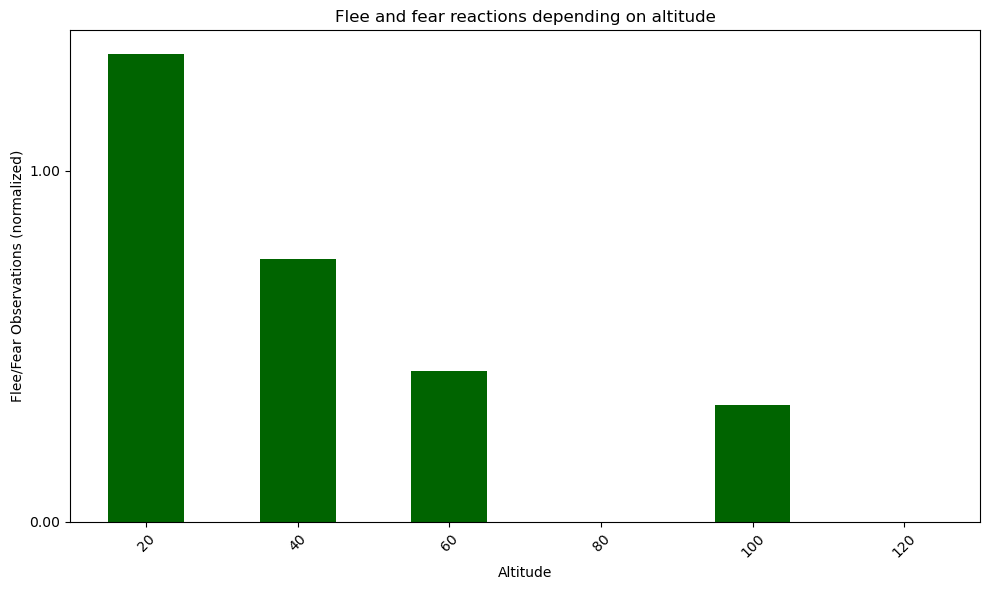

In [61]:
AJ_data = data[data['Test_ID'].str.startswith('AJ')]

grouped_data = AJ_data.groupby('Altitude')['AF_Flee/Fear'].sum()

observation_counts = AJ_data.groupby('Altitude').size()

normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='darkgreen')

plt.title('Flee and fear reactions depending on altitude')
plt.xlabel('Altitude')
plt.ylabel('Flee/Fear Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Flee/fear reactions for Utali pride

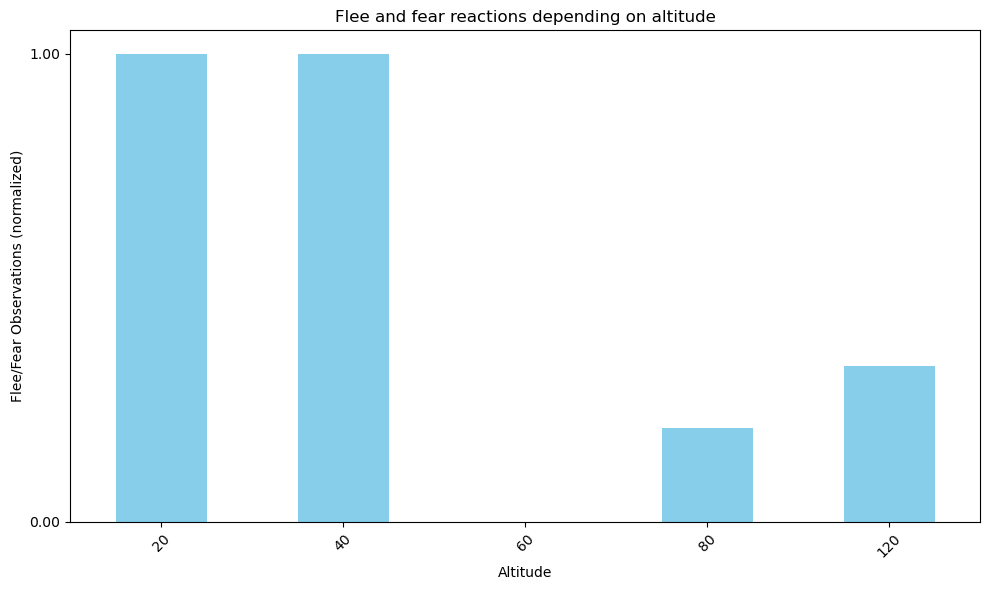

In [8]:
UT_data = data[data['Test_ID'].str.startswith('UT')]

grouped_data = UT_data.groupby('Altitude')['AF_Flee/Fear'].sum()

observation_counts = UT_data.groupby('Altitude').size()

normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='skyblue')

plt.title('Flee and fear reactions depending on altitude')
plt.xlabel('Altitude')
plt.ylabel('Flee/Fear Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Flee/fear reactions for Wanjiku pride

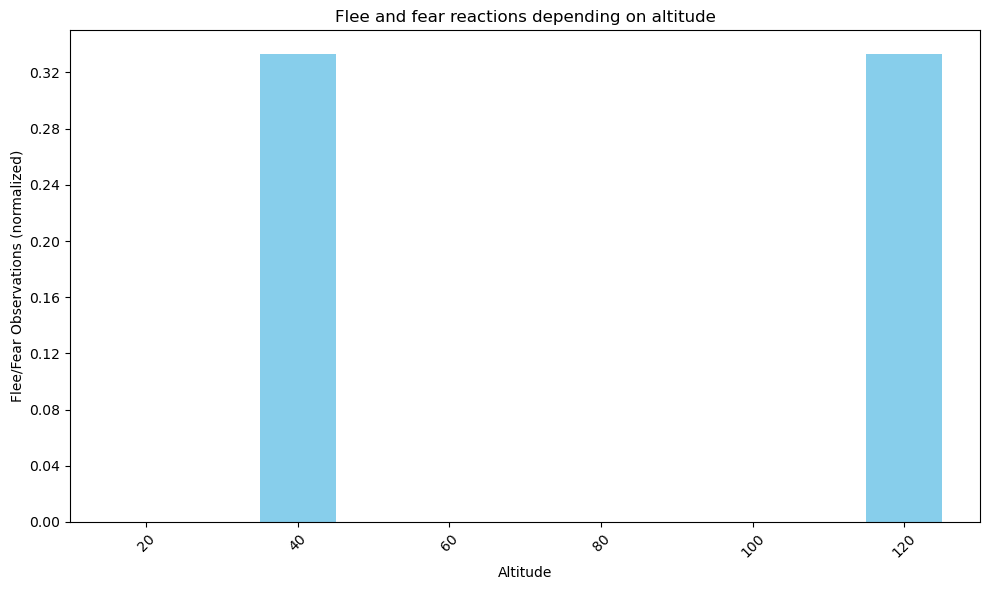

In [9]:
WA_data = data[data['Test_ID'].str.startswith('WA')]

grouped_data = WA_data.groupby('Altitude')['AF_Flee/Fear'].sum()

observation_counts = WA_data.groupby('Altitude').size()

normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='skyblue')

plt.title('Flee and fear reactions depending on altitude')
plt.xlabel('Altitude')
plt.ylabel('Flee/Fear Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exploratory reactions

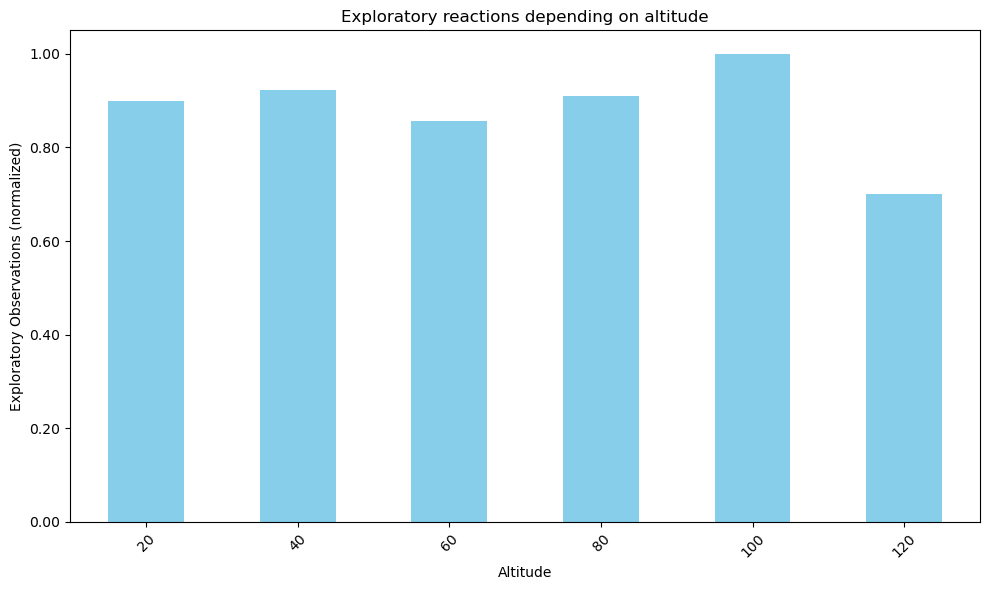

In [4]:
# Group the data by 'Altitude' and sum the 'AF_Exploratory' values
grouped_data = data.groupby('Altitude')['AF_Exploratory'].sum()

observation_counts = data.groupby('Altitude').size()

normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='skyblue')

plt.title('Exploratory reactions depending on altitude')
plt.xlabel('Altitude')
plt.ylabel('Exploratory Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Calm reactions

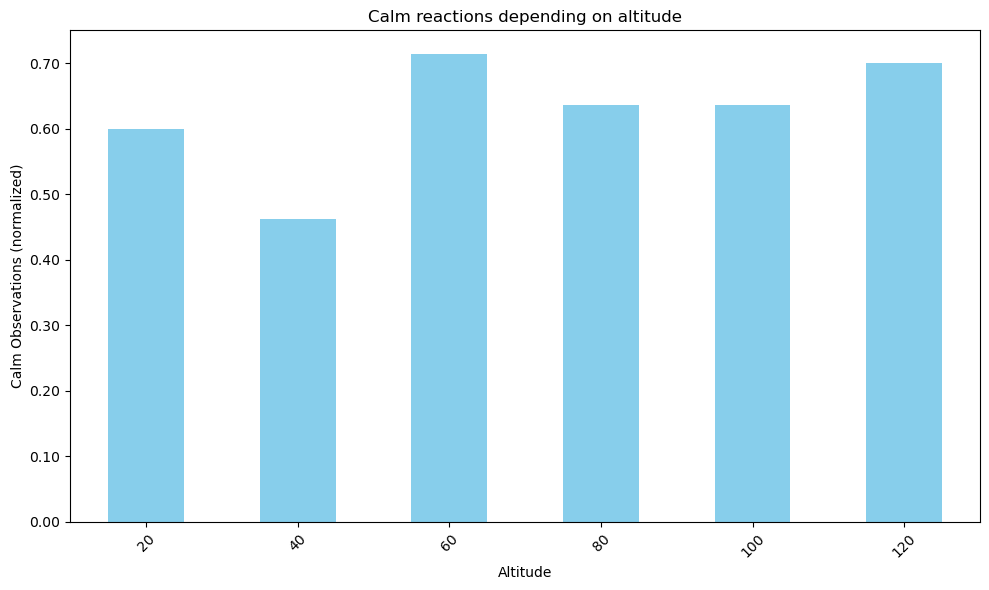

In [29]:
# Group the data by 'Altitude' and sum the 'AF_Exploratory' values
grouped_data = data.groupby('Altitude')['AF_Calm'].sum()

observation_counts = data.groupby('Altitude').size()

normalized_data = grouped_data / observation_counts

# Plot 
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='skyblue')

plt.title('Calm reactions depending on altitude')
plt.xlabel('Altitude')
plt.ylabel('Calm Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Behavioral states vs pride with or without cubs

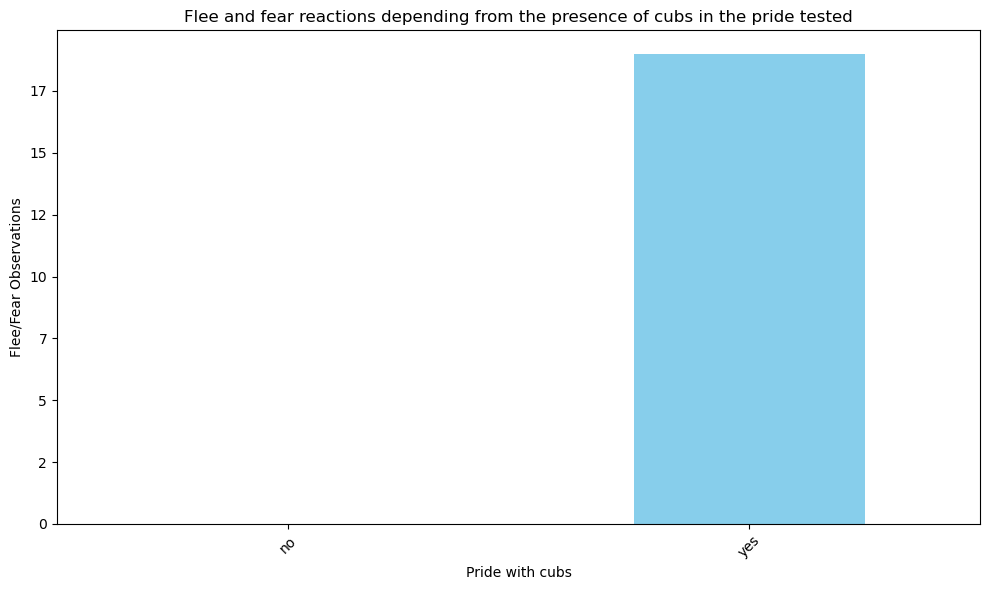

In [51]:
# Flee/Fear
# Group the data by 'Pride_with_cubs' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('Pride_with_cubs')['AF_Flee/Fear'].sum()

# Plot 
plt.figure(figsize=(10, 6))
ax = grouped_data.plot(kind='bar', color='skyblue')

plt.title('Flee and fear reactions depending from the presence of cubs in the pride tested')
plt.xlabel('Pride with cubs')
plt.ylabel('Flee/Fear Observations')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))
ax.set_xticklabels(['no', 'yes'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Behavioral states vs cubs present during the test

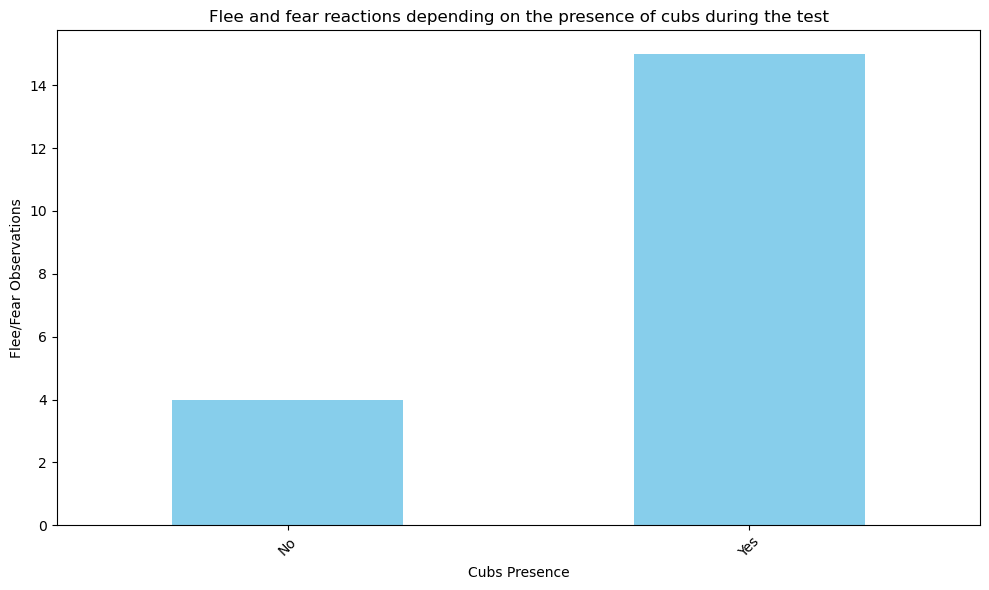

In [7]:
# Flee/Fear
# Create a new column 'Cubs_Presence' based on 'DroneVIDEO_N_c'
data['Cubs_Presence'] = data['DroneVIDEO_N_c'].apply(lambda x: 'No' if x == 0 else 'Yes')

# Group the data by 'Cubs_Presence' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('Cubs_Presence')['AF_Flee/Fear'].sum()
grouped_data = grouped_data.reindex(['No', 'Yes'])

# Plot
plt.figure(figsize=(10, 6))
ax = grouped_data.plot(kind='bar', color='skyblue')

plt.title('Flee and fear reactions depending on the presence of cubs during the test')
plt.xlabel('Cubs Presence')
plt.ylabel('Flee/Fear Observations')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

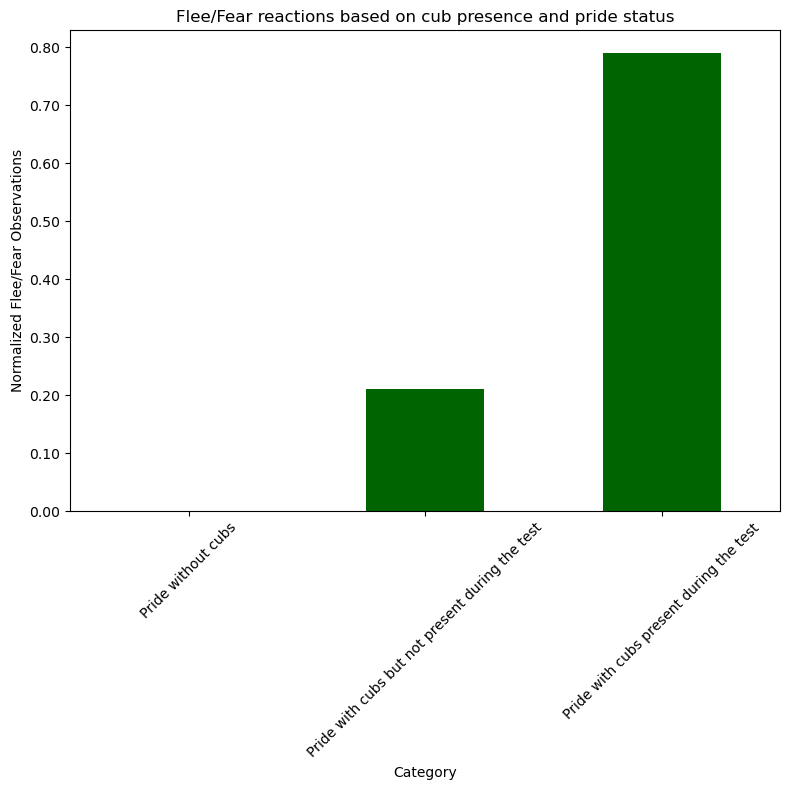

In [6]:
# Flee/Fear
# Create a new column 'Cubs_Presence' based on 'DroneVIDEO_N_c'
data['Cubs_Presence'] = data['DroneVIDEO_N_c'].apply(lambda x: 'No' if x == 0 else 'Yes')

# Initialize a dictionary to store the results
results = {
    'Category': ['Pride without cubs', 'Pride with cubs but not present during the test', 'Pride with cubs present during the test'],
    'Flee/Fear Observations': [0, 0, 0]
}

# Calculate the sum for each category using the correct values
results['Flee/Fear Observations'][0] = data[(data['Pride_with_cubs'] == 0)]['AF_Flee/Fear'].sum()
results['Flee/Fear Observations'][1] = data[(data['Pride_with_cubs'] == 1) & (data['Cubs_Presence'] == 'No')]['AF_Flee/Fear'].sum()
results['Flee/Fear Observations'][2] = data[(data['Pride_with_cubs'] == 1) & (data['Cubs_Presence'] == 'Yes')]['AF_Flee/Fear'].sum()

# Normalize the data
total_observations = sum(results['Flee/Fear Observations'])
results['Normalized Observations'] = [obs / total_observations for obs in results['Flee/Fear Observations']]

# Convert results to DataFrame
plot_data = pd.DataFrame(results)

# Plot with increased size
fig, ax = plt.subplots(figsize=(8, 8))  # Use subplots to control figure size
plot_data.plot(kind='bar', x='Category', y='Normalized Observations', color='darkgreen', legend=False, ax=ax)

plt.title('Flee/Fear reactions based on cub presence and pride status')
plt.ylabel('Normalized Flee/Fear Observations')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=False))

plt.xticks(rotation=45)
plt.savefig('flee and fear reactions based on cub presence and pride status.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

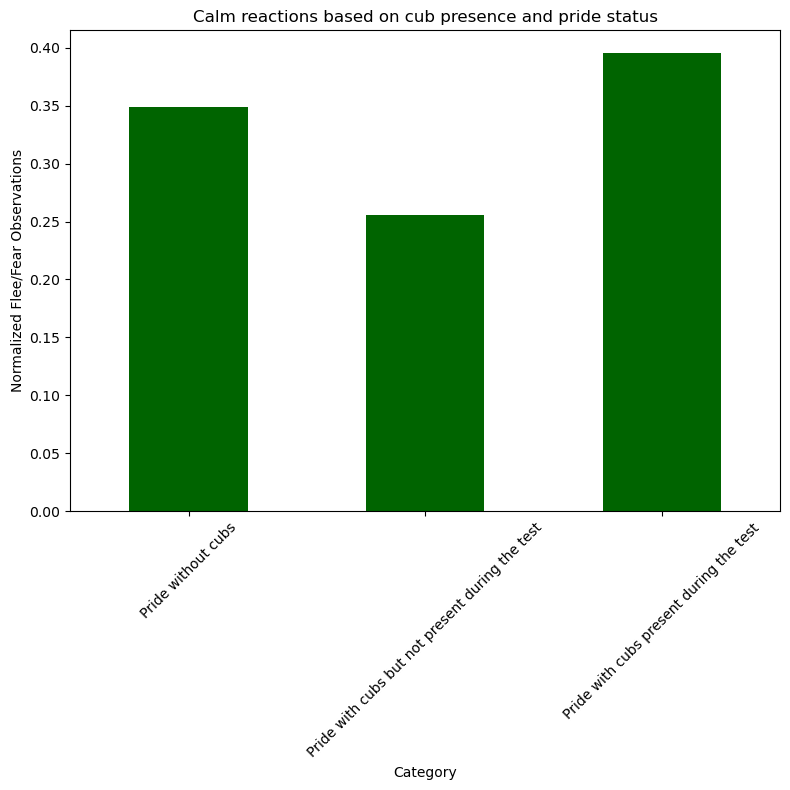

In [8]:
# calm
data['Cubs_Presence'] = data['DroneVIDEO_N_c'].apply(lambda x: 'No' if x == 0 else 'Yes')

# Initialize a dictionary to store the results
results = {
    'Category': ['Pride without cubs', 'Pride with cubs but not present during the test', 'Pride with cubs present during the test'],
    'Calm Observations': [0, 0, 0]
}

# Calculate the sum for each category using the correct values
results['Calm Observations'][0] = data[(data['Pride_with_cubs'] == 0)]['AF_Calm'].sum()
results['Calm Observations'][1] = data[(data['Pride_with_cubs'] == 1) & (data['Cubs_Presence'] == 'No')]['AF_Calm'].sum()
results['Calm Observations'][2] = data[(data['Pride_with_cubs'] == 1) & (data['Cubs_Presence'] == 'Yes')]['AF_Calm'].sum()

# Normalize the data
total_observations = sum(results['Calm Observations'])
results['Normalized Observations'] = [obs / total_observations for obs in results['Calm Observations']]

# Convert results to DataFrame
plot_data = pd.DataFrame(results)

# Plot with increased size
fig, ax = plt.subplots(figsize=(8, 8))  # Use subplots to control figure size
plot_data.plot(kind='bar', x='Category', y='Normalized Observations', color='darkgreen', legend=False, ax=ax)

plt.title('Calm reactions based on cub presence and pride status')
plt.ylabel('Normalized Flee/Fear Observations')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=False))

plt.xticks(rotation=45)
plt.savefig('Calm reactions based on cub presence and pride status.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

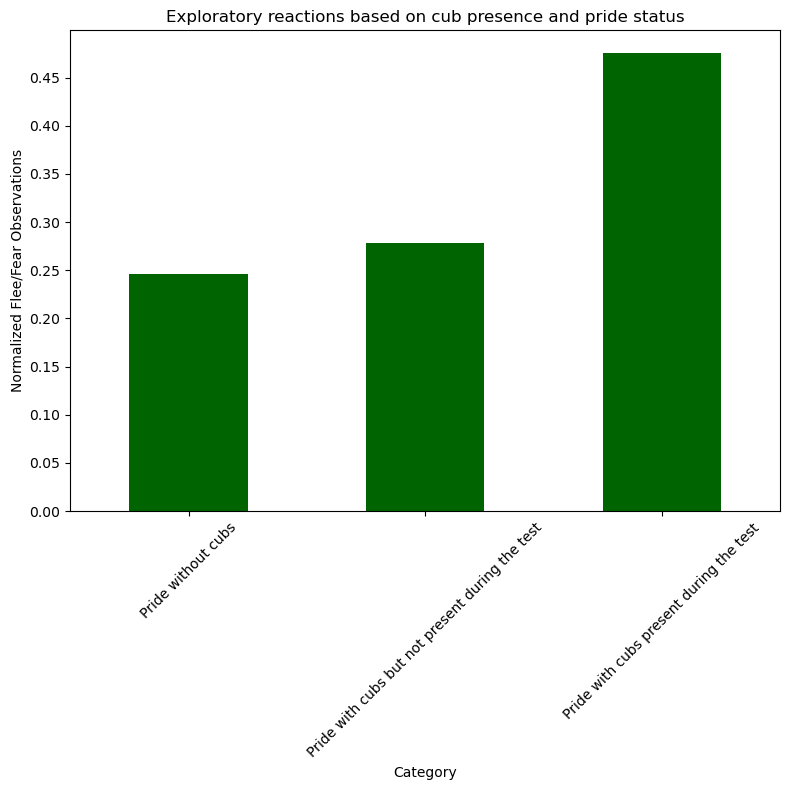

In [5]:
# Exploratory
data['Cubs_Presence'] = data['DroneVIDEO_N_c'].apply(lambda x: 'No' if x == 0 else 'Yes')

# Initialize a dictionary to store the results
results = {
    'Category': ['Pride without cubs', 'Pride with cubs but not present during the test', 'Pride with cubs present during the test'],
    'Exploratory Observations': [0, 0, 0]
}

# Calculate the sum for each category using the correct values
results['Exploratory Observations'][0] = data[(data['Pride_with_cubs'] == 0)]['AF_Exploratory'].sum()
results['Exploratory Observations'][1] = data[(data['Pride_with_cubs'] == 1) & (data['Cubs_Presence'] == 'No')]['AF_Exploratory'].sum()
results['Exploratory Observations'][2] = data[(data['Pride_with_cubs'] == 1) & (data['Cubs_Presence'] == 'Yes')]['AF_Exploratory'].sum()

# Normalize the data
total_observations = sum(results['Exploratory Observations'])
results['Normalized Observations'] = [obs / total_observations for obs in results['Exploratory Observations']]

# Convert results to DataFrame
plot_data = pd.DataFrame(results)

# Plot with increased size
fig, ax = plt.subplots(figsize=(8, 8))  # Use subplots to control figure size
plot_data.plot(kind='bar', x='Category', y='Normalized Observations', color='darkgreen', legend=False, ax=ax)

plt.title('Exploratory reactions based on cub presence and pride status')
plt.ylabel('Normalized Flee/Fear Observations')

plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(MaxNLocator(integer=False))

plt.xticks(rotation=45)
plt.savefig('Exploratory reactions based on cub presence and pride status.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Behavioral states vs male adult presence during the test

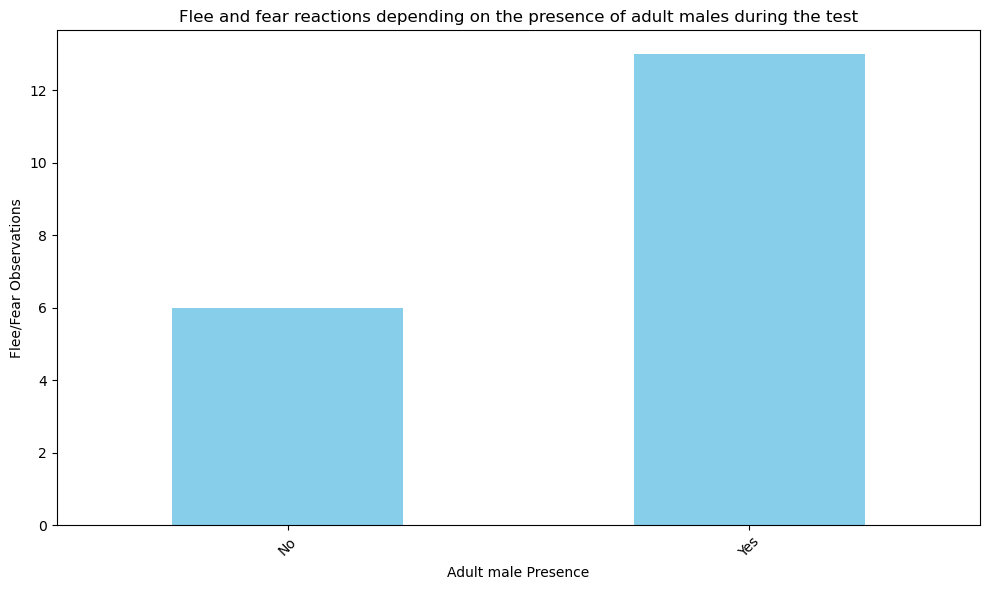

In [14]:
# Flee/Fear
# Create a new column 'Cubs_Presence' based on 'DroneVIDEO_N_c'
data['AdultMale_Presence'] = data['DroneVIDEO_N_M'].apply(lambda x: 'No' if x == 0 else 'Yes')

# Group the data by 'Cubs_Presence' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('AdultMale_Presence')['AF_Flee/Fear'].sum()
grouped_data = grouped_data.reindex(['No', 'Yes'])

# Plot
plt.figure(figsize=(10, 6))
ax = grouped_data.plot(kind='bar', color='skyblue')

plt.title('Flee and fear reactions depending on the presence of adult males during the test')
plt.xlabel('Adult male Presence')
plt.ylabel('Flee/Fear Observations')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

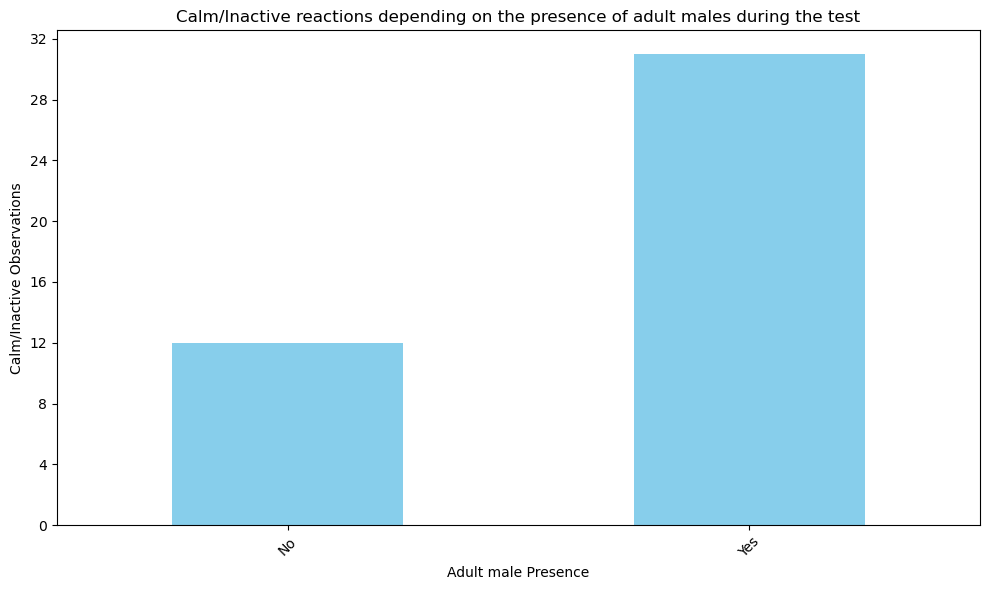

In [9]:
# Calm/Inactive
# Create a new column 'Cubs_Presence' based on 'DroneVIDEO_N_c'
data['AdultMale_Presence'] = data['DroneVIDEO_N_M'].apply(lambda x: 'No' if x == 0 else 'Yes')

# Group the data by 'Cubs_Presence' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('AdultMale_Presence')['AF_Calm'].sum()
grouped_data = grouped_data.reindex(['No', 'Yes'])

# Plot
plt.figure(figsize=(10, 6))
ax = grouped_data.plot(kind='bar', color='skyblue')

plt.title('Calm/Inactive reactions depending on the presence of adult males during the test')
plt.xlabel('Adult male Presence')
plt.ylabel('Calm/Inactive Observations')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

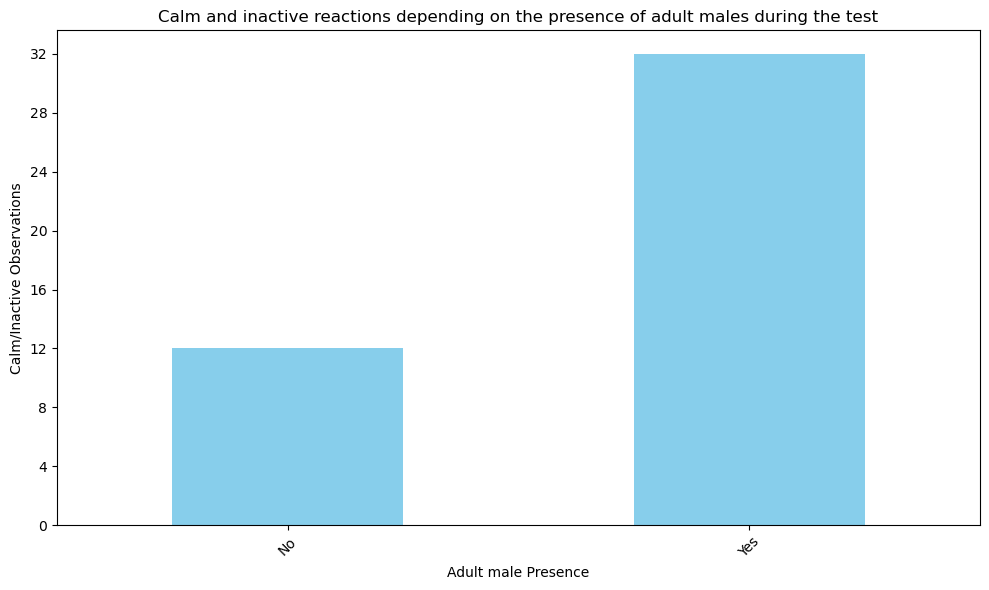

In [27]:
# Create a new column 'Cubs_Presence' based on 'DroneVIDEO_N_c'
data['AdultMale_Presence'] = data['DroneVIDEO_N_M'].apply(lambda x: 'No' if x == 0 else 'Yes')

# Group the data by 'Cubs_Presence' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('AdultMale_Presence')['AF_Calm/Inactive'].sum()
grouped_data = grouped_data.reindex(['No', 'Yes'])

# Plot
plt.figure(figsize=(10, 6))
ax = grouped_data.plot(kind='bar', color='skyblue')

plt.title('Calm and inactive reactions depending on the presence of adult males during the test')
plt.xlabel('Adult male Presence')
plt.ylabel('Calm/Inactive Observations')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

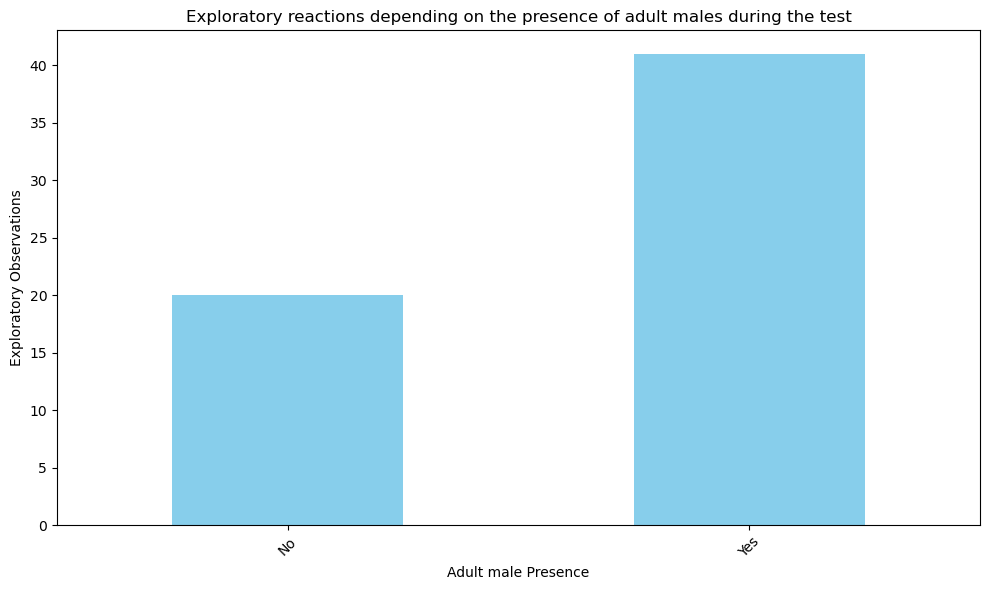

In [3]:
# Exploratory
# Create a new column 'Cubs_Presence' based on 'DroneVIDEO_N_c'
data['AdultMale_Presence'] = data['DroneVIDEO_N_M'].apply(lambda x: 'No' if x == 0 else 'Yes')

# Group the data by 'Cubs_Presence' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('AdultMale_Presence')['AF_Exploratory'].sum()
grouped_data = grouped_data.reindex(['No', 'Yes'])

# Plot
plt.figure(figsize=(10, 6))
ax = grouped_data.plot(kind='bar', color='skyblue')

plt.title('Exploratory reactions depending on the presence of adult males during the test')
plt.xlabel('Adult male Presence')
plt.ylabel('Exploratory Observations')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Behavioral states vs kill presence

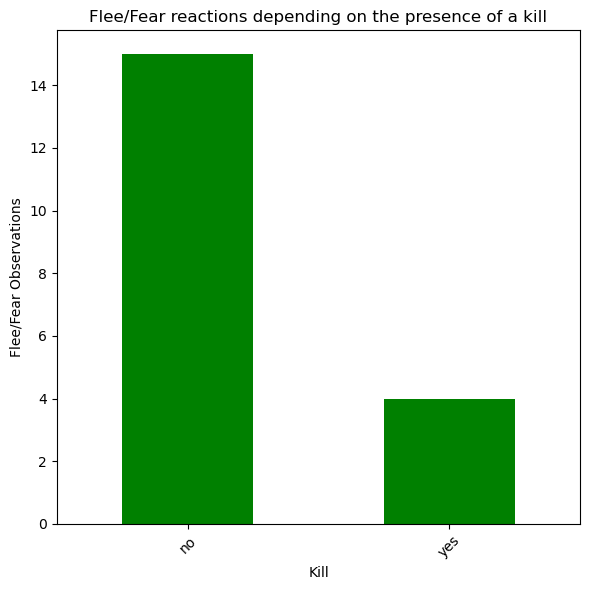

In [113]:
# Flee/Fear
# Group the data by 'Kill' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('Kill')['AF_Flee/Fear'].sum()

# Plot 
plt.figure(figsize=(6, 6))
ax = grouped_data.plot(kind='bar', color='green')

plt.title('Flee/Fear reactions depending on the presence of a kill')
plt.xlabel('Kill')
plt.ylabel('Flee/Fear Observations')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))
ax.set_xticklabels(['no', 'yes'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('presence of a kill.png', bbox_inches='tight')
plt.show()

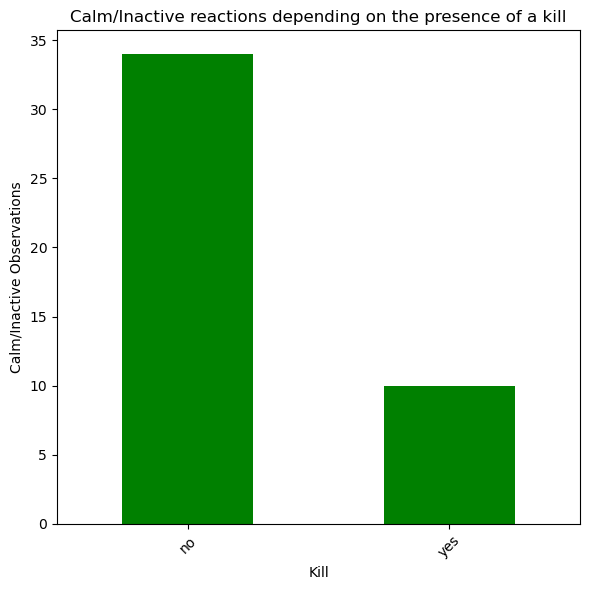

In [32]:
# Calm/Inactive

grouped_data = data.groupby('Kill')['AF_Calm/Inactive'].sum()

# Plot 
plt.figure(figsize=(6, 6))
ax = grouped_data.plot(kind='bar', color='green')

plt.title('Calm/Inactive reactions depending on the presence of a kill')
plt.xlabel('Kill')
plt.ylabel('Calm/Inactive Observations')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))
ax.set_xticklabels(['no', 'yes'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('presence of a kill.png', bbox_inches='tight')
plt.show()

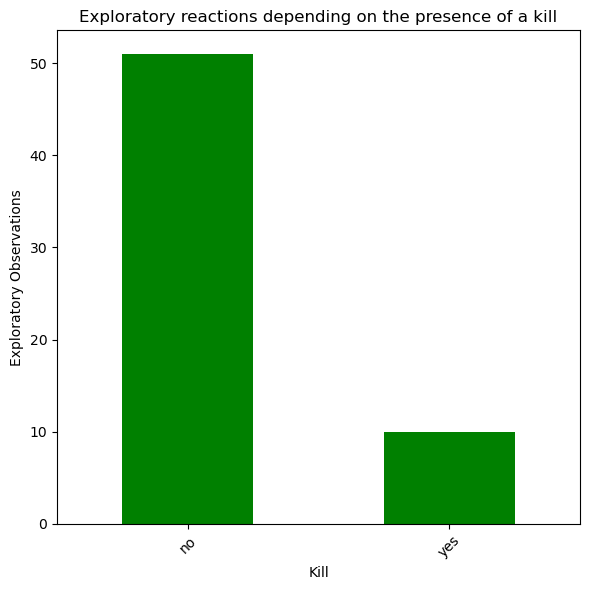

In [33]:
# Exploratory

grouped_data = data.groupby('Kill')['AF_Exploratory'].sum()

# Plot 
plt.figure(figsize=(6, 6))
ax = grouped_data.plot(kind='bar', color='green')

plt.title('Exploratory reactions depending on the presence of a kill')
plt.xlabel('Kill')
plt.ylabel('Exploratory Observations')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: int(x)))
ax.set_xticklabels(['no', 'yes'])
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('presence of a kill.png', bbox_inches='tight')
plt.show()

## Behavioral states vs habitat

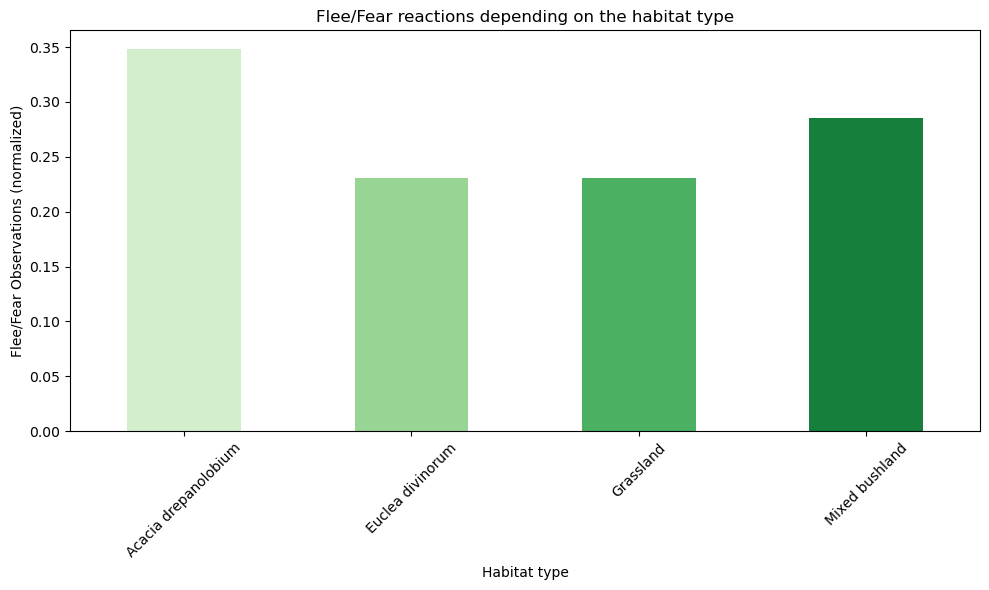

In [4]:
# Flee/Fear

observation_counts = data.groupby('vegetation').size()
grouped_data = data.groupby('vegetation')['AF_Flee/Fear'].sum()
normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))

# Create a colormap
cmap = plt.get_cmap('Greens')
colors = cmap(np.linspace(0.2, 0.8, len(normalized_data)))

# Plot with gradient colors
normalized_data.plot(kind='bar', color=colors)

plt.title('Flee/Fear reactions depending on the habitat type')
plt.xlabel('Habitat type')
plt.ylabel('Flee/Fear Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.xticks(rotation=45)
plt.savefig('habitat type reactions.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

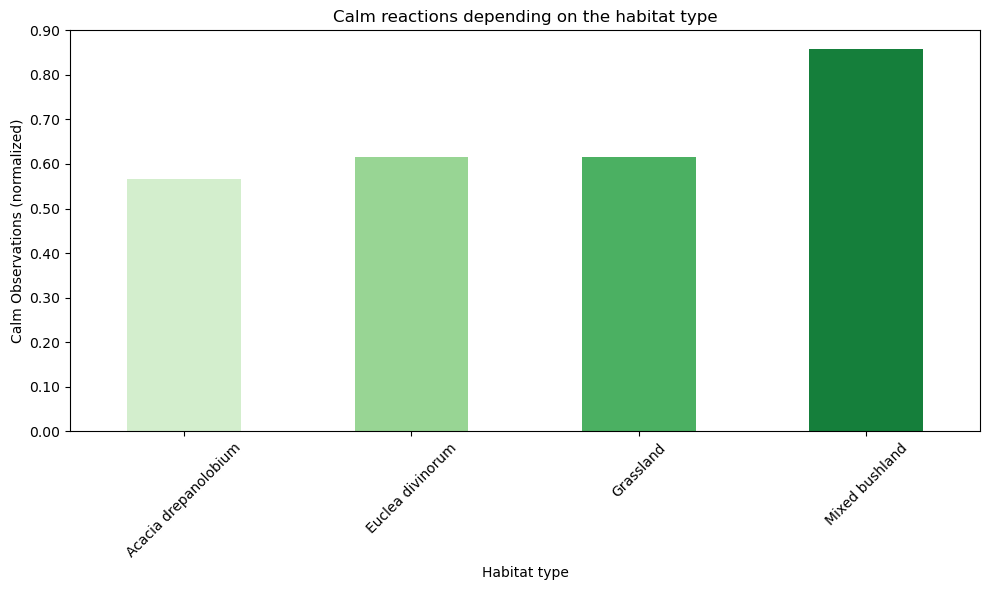

In [10]:
# Calm/Inactive

observation_counts = data.groupby('vegetation').size()
grouped_data = data.groupby('vegetation')['AF_Calm'].sum()
normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))

# Create a colormap
cmap = plt.get_cmap('Greens')
colors = cmap(np.linspace(0.2, 0.8, len(normalized_data)))

# Plot with gradient colors
normalized_data.plot(kind='bar', color=colors)

plt.title('Calm reactions depending on the habitat type')
plt.xlabel('Habitat type')
plt.ylabel('Calm Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.xticks(rotation=45)
plt.savefig('habitat type reactions.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

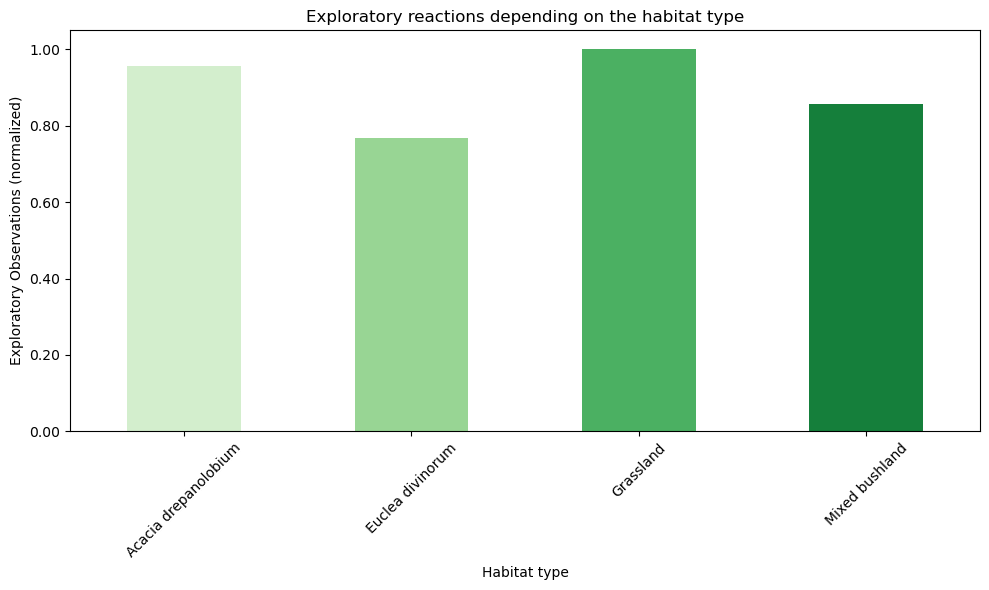

In [35]:
# Exploratory

observation_counts = data.groupby('vegetation').size()
grouped_data = data.groupby('vegetation')['AF_Exploratory'].sum()
normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))

# Create a colormap
cmap = plt.get_cmap('Greens')
colors = cmap(np.linspace(0.2, 0.8, len(normalized_data)))

# Plot with gradient colors
normalized_data.plot(kind='bar', color=colors)

plt.title('Exploratory reactions depending on the habitat type')
plt.xlabel('Habitat type')
plt.ylabel('Exploratory Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.xticks(rotation=45)
plt.savefig('habitat type reactions.png', bbox_inches='tight')
plt.tight_layout()
plt.show()

## Behavioral states vs take off distance

/var/folders/1x/wx981vzx1vjfqsxgpfvd3mhc0000gn/T/ipykernel_28055/3539154772.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby('Distance_Group')['AF_Flee/Fear'].sum()
/var/folders/1x/wx981vzx1vjfqsxgpfvd3mhc0000gn/T/ipykernel_28055/3539154772.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observation_counts = data.groupby('Distance_Group').size()


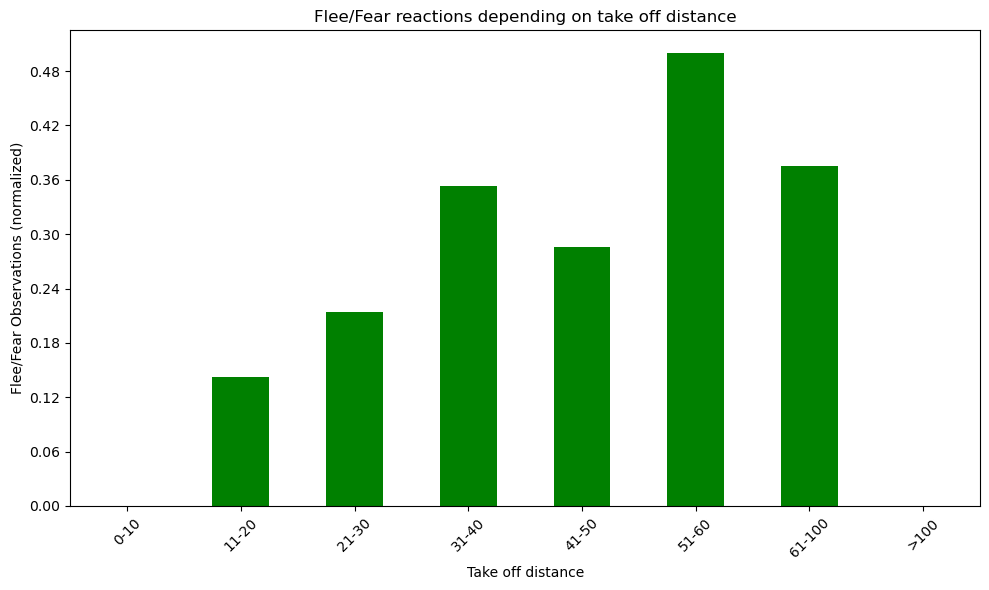

In [104]:
# Flee/Fear
# grouped the distance values
bins = [0, 10, 20, 30, 40, 50, 60, 100, float('inf')]
labels = ['0-10','11-20','21-30','31-40','41-50','51-60','61-100', '>100']

data['Distance_Group'] = pd.cut(data['BF_Distance_averaged'], bins=bins, labels=labels, right=False)

grouped_data = data.groupby('Distance_Group')['AF_Flee/Fear'].sum()

observation_counts = data.groupby('Distance_Group').size()

normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='green')

plt.title('Flee/Fear reactions depending on take off distance')
plt.xlabel('Take off distance')
plt.ylabel('Flee/Fear Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_22321/3026592681.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby('Distance_Group')['AF_Calm/Inactive'].sum()
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_22321/3026592681.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observation_counts = data.groupby('Distance_Group').size()


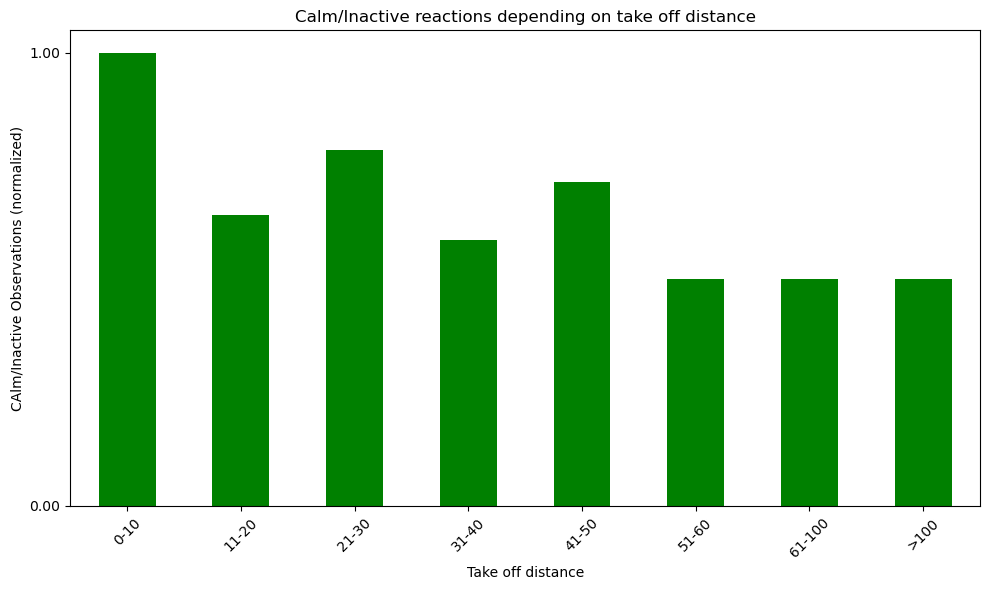

In [36]:
# Calm/Inactive
# grouped the distance values
bins = [0, 10, 20, 30, 40, 50, 60, 100, float('inf')]
labels = ['0-10','11-20','21-30','31-40','41-50','51-60','61-100', '>100']

data['Distance_Group'] = pd.cut(data['BF_Distance_averaged'], bins=bins, labels=labels, right=False)

grouped_data = data.groupby('Distance_Group')['AF_Calm/Inactive'].sum()

observation_counts = data.groupby('Distance_Group').size()

normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='green')

plt.title('Calm/Inactive reactions depending on take off distance')
plt.xlabel('Take off distance')
plt.ylabel('CAlm/Inactive Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Behavioral states vs time of the day

/var/folders/1x/wx981vzx1vjfqsxgpfvd3mhc0000gn/T/ipykernel_89196/2301957322.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby('Time_Category')['AF_Flee/Fear'].sum()
/var/folders/1x/wx981vzx1vjfqsxgpfvd3mhc0000gn/T/ipykernel_89196/2301957322.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observation_counts = data.groupby('Time_Category').size()


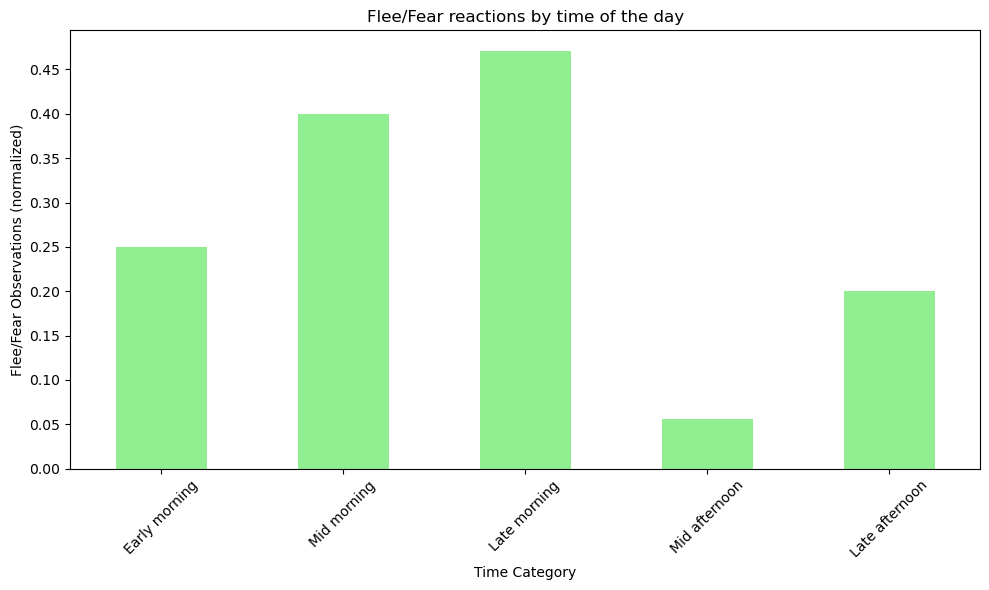

In [27]:
# Flee/Fear
# Convert 'Time' to datetime
data['Time'] = pd.to_datetime(data['Time'], format='%H:%M:%S').dt.time

# Function to categorize time
def categorize_time(time):
    if time >= pd.to_datetime('07:00').time() and time < pd.to_datetime('09:00').time():
        return 'Early morning'
    if time >= pd.to_datetime('09:00').time() and time < pd.to_datetime('11:00').time():
        return 'Mid morning'
    elif time >= pd.to_datetime('11:00').time() and time < pd.to_datetime('13:00').time():
        return 'Late morning'
    elif time >= pd.to_datetime('15:00').time() and time < pd.to_datetime('17:00').time():
        return 'Mid afternoon'
    elif time >= pd.to_datetime('17:00').time() and time < pd.to_datetime('19:00').time():
        return 'Late afternoon'
    else:
        return 'Other'

data['Time_Category'] = data['Time'].apply(categorize_time)

category_order = pd.CategoricalDtype(
    categories=['Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon'],
    ordered=True
)

data['Time_Category'] = data['Time_Category'].astype(category_order)

# Group the data by 'Time_Category' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('Time_Category')['AF_Flee/Fear'].sum()

observation_counts = data.groupby('Time_Category').size()

normalized_data = grouped_data / observation_counts


# Plot 
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='lightgreen')

plt.title('Flee/Fear reactions by time of the day')
plt.xlabel('Time Category')
plt.ylabel('Flee/Fear Observations (normalized)')

# Format y-axis to remove decimals
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))


# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('time of the day.png', bbox_inches='tight')
plt.show()

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_22321/585184782.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby('Time_Category')['AF_Calm/Inactive'].sum()
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_22321/585184782.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observation_counts = data.groupby('Time_Category').size()


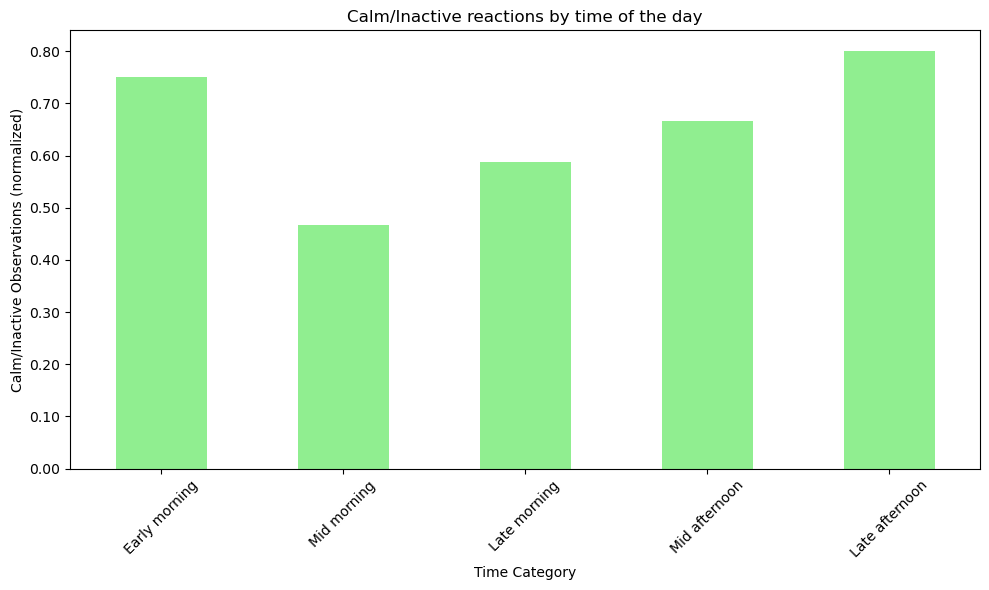

In [29]:
# Calm/Inactive
# Convert 'Time' to datetime
data['Time'] = pd.to_datetime(data['Time'], format='%H:%M:%S').dt.time

# Function to categorize time
def categorize_time(time):
    if time >= pd.to_datetime('07:00').time() and time < pd.to_datetime('09:00').time():
        return 'Early morning'
    if time >= pd.to_datetime('09:00').time() and time < pd.to_datetime('11:00').time():
        return 'Mid morning'
    elif time >= pd.to_datetime('11:00').time() and time < pd.to_datetime('13:00').time():
        return 'Late morning'
    elif time >= pd.to_datetime('15:00').time() and time < pd.to_datetime('17:00').time():
        return 'Mid afternoon'
    elif time >= pd.to_datetime('17:00').time() and time < pd.to_datetime('19:00').time():
        return 'Late afternoon'
    else:
        return 'Other'

data['Time_Category'] = data['Time'].apply(categorize_time)

category_order = pd.CategoricalDtype(
    categories=['Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon'],
    ordered=True
)

data['Time_Category'] = data['Time_Category'].astype(category_order)

# Group the data by 'Time_Category' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('Time_Category')['AF_Calm/Inactive'].sum()

observation_counts = data.groupby('Time_Category').size()

normalized_data = grouped_data / observation_counts


# Plot 
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='lightgreen')

plt.title('Calm/Inactive reactions by time of the day')
plt.xlabel('Time Category')
plt.ylabel('Calm/Inactive Observations (normalized)')

# Format y-axis to remove decimals
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))


# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('time of the day.png', bbox_inches='tight')
plt.show()

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_22321/2482775972.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby('Time_Category')['AF_Exploratory'].sum()
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_22321/2482775972.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  observation_counts = data.groupby('Time_Category').size()


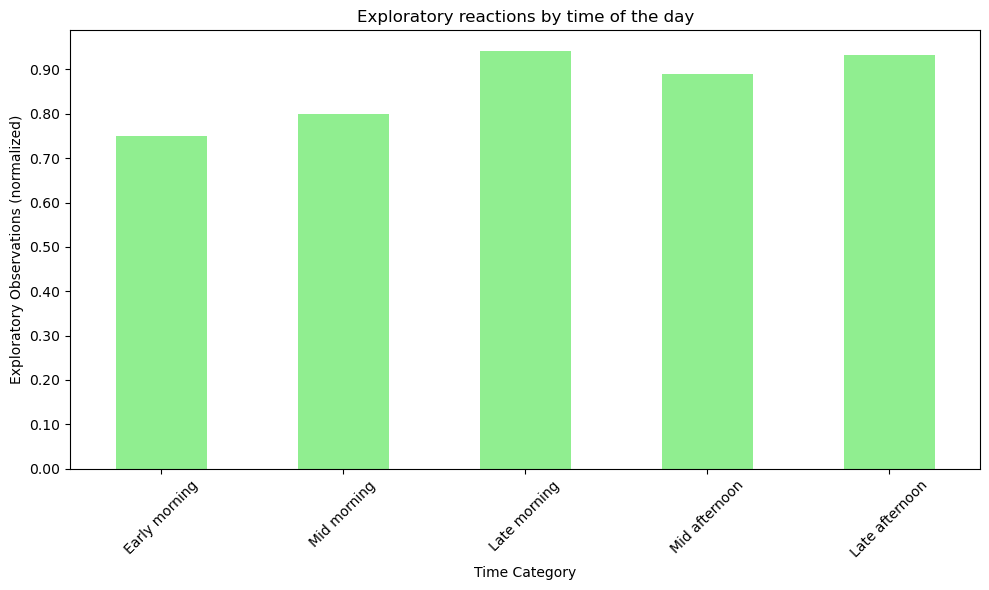

In [30]:
# Exploratory
# Convert 'Time' to datetime
data['Time'] = pd.to_datetime(data['Time'], format='%H:%M:%S').dt.time

# Function to categorize time
def categorize_time(time):
    if time >= pd.to_datetime('07:00').time() and time < pd.to_datetime('09:00').time():
        return 'Early morning'
    if time >= pd.to_datetime('09:00').time() and time < pd.to_datetime('11:00').time():
        return 'Mid morning'
    elif time >= pd.to_datetime('11:00').time() and time < pd.to_datetime('13:00').time():
        return 'Late morning'
    elif time >= pd.to_datetime('15:00').time() and time < pd.to_datetime('17:00').time():
        return 'Mid afternoon'
    elif time >= pd.to_datetime('17:00').time() and time < pd.to_datetime('19:00').time():
        return 'Late afternoon'
    else:
        return 'Other'

data['Time_Category'] = data['Time'].apply(categorize_time)

category_order = pd.CategoricalDtype(
    categories=['Early morning', 'Mid morning', 'Late morning', 'Mid afternoon', 'Late afternoon'],
    ordered=True
)

data['Time_Category'] = data['Time_Category'].astype(category_order)

# Group the data by 'Time_Category' and sum the 'AF_Flee/Fear' values
grouped_data = data.groupby('Time_Category')['AF_Exploratory'].sum()

observation_counts = data.groupby('Time_Category').size()

normalized_data = grouped_data / observation_counts


# Plot 
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='lightgreen')

plt.title('Exploratory reactions by time of the day')
plt.xlabel('Time Category')
plt.ylabel('Exploratory Observations (normalized)')

# Format y-axis to remove decimals
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.gca().yaxis.set_major_locator(plt.MaxNLocator(integer=True))


# Show the plot
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('time of the day.png', bbox_inches='tight')
plt.show()

In [28]:
# Count the number of rows for each time category
category_counts = data['Time_Category'].value_counts()

# Print the counts
print(category_counts)

Time_Category
Mid afternoon     18
Late morning      17
Mid morning       15
Late afternoon    15
Early morning      4
Name: count, dtype: int64


## Behavioral states vs Temperature

In [15]:
# data preparation 




data = df[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Agonistic', 'BF_Aggressive/Flee', 'BF_Fear', 'BF_Stereotypic', 
'BF_Vocalization', 'BF_Active/Exploratory', 'BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Affiliative_Reproductive', 
'BF_Loc', 'BF_Calm', 'BF_Inactive', 'AF_Agonistic', 'AF_Aggressive/Flee', 'AF_Fear', 'AF_Stereotypic', 'AF_Vocalization', 
'AF_Active/Exploratory', 'AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 
'AF_Calm', 'AF_Inactive', 'Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'prides', 'Temperature', 'Wind']]

data = data.rename(columns={'BF_Aggressive/Flee': 'BF_Flee'})  
data = data.rename(columns={'AF_Aggressive/Flee': 'AF_Flee'})  
data = data.rename(columns={'BF_Active/Exploratory': 'BF_Exploratory'})  
data = data.rename(columns={'AF_Active/Exploratory': 'AF_Exploratory'})  
data = data[data['Species'] == 'Lion']

data['Pride_ID'] = data['Test_ID'].str[:2]

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract the week number and create a new 'Week' column
data['Week'] = data['Date'].dt.isocalendar().week

# Display the resulting DataFrame with the new 'Week' column
print(data[['Date', 'Week']])

columns_to_transform = [
    'BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic', 
    'BF_Vocalization', 'BF_Exploratory', 'BF_Marking', 'BF_Maintenance', 
    'BF_Feeding', 'BF_Affiliative_Reproductive', 'BF_Loc', 'BF_Calm', 
    'BF_Inactive', 'AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic', 
    'AF_Vocalization', 'AF_Exploratory', 'AF_Marking', 'AF_Maintenance', 
    'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 'AF_Calm', 
    'AF_Inactive',  'Kill', 'Pride_with_cubs'
]

# Transform the values
data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))

# Define a function to convert positive sums to 1
def convert_to_binary(value):
    return 1 if value > 0 else value


# Combine columns as specified and apply the conversion function
data['BF_Flee/Fear'] = data[['BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['BF_Calm/Inactive'] = data[['BF_Calm', 'BF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['BF_Feeding/Affiliative/Mating'] = data[['BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Vocalization', 'BF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)
data['AF_Flee/Fear'] = data[['AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['AF_Calm/Inactive'] = data[['AF_Calm', 'AF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['AF_Feeding/Affiliative/Mating'] = data[['AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Vocalization', 'AF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)

# Display the resulting DataFrame
print(data[['BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating']])

# --- Altitude Transformation ---
data['log_altitude'] = np.log(data['Altitude'])
data['z_log_altitude'] = (data['log_altitude'] - data['log_altitude'].mean()) / data['log_altitude'].std()

data = data[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 'BF_Loc', 'BF_Exploratory',
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating', 'AF_Loc', 'AF_Exploratory','Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'log_altitude', 'z_log_altitude', 'prides', 'Temperature', 'Wind']]


def melt_behavior_data(data, prefix):
    behavior_columns = [
        f'{prefix}_Flee/Fear', f'{prefix}_Calm/Inactive', f'{prefix}_Feeding/Affiliative/Mating', f'{prefix}_Loc',  f'{prefix}_Exploratory'
    ]
    # Include 'Pride_with_cubs' and 'DroneVIDEO_N_c' in id_vars to retain them
    melted_data = data.melt(
        id_vars=['Test_ID', 'Date', 'Species', 'Altitude','z_log_altitude', 'Pride_with_cubs', 'DroneVIDEO_N_c', 'prides', 'Temperature', 'Wind'],
        value_vars=behavior_columns,
        var_name='behavior_type',
        value_name='behavior_count'
    )
    melted_data['before_after'] = 0 if prefix == 'BF' else 1
    melted_data['behavior_type'] = melted_data['behavior_type'].str.replace(f'{prefix}_', '')
    return melted_data[melted_data['behavior_count'] > 0]

# Melt the data for 'before' and 'after'
before_data = melt_behavior_data(data, 'BF')
after_data = melt_behavior_data(data, 'AF')

# Concatenate the melted data
transformed_data = pd.concat([before_data, after_data], ignore_index=True)

# Use z_log_altitude only for 'after' observations
transformed_data.loc[transformed_data['before_after'] == 0, 'z_log_altitude'] = np.nan
transformed_data['z_log_altitude'].fillna(0, inplace=True)

# Select relevant columns
transformed_data = transformed_data[['Test_ID', 'Date', 'Temperature', 'Wind', 'Species', 'Altitude', 'before_after', 'behavior_type', 'z_log_altitude', 'Pride_with_cubs', 'DroneVIDEO_N_c', 'prides']]


         Date  Week
0  2024-11-07    45
1  2024-11-07    45
2  2024-11-07    45
3  2024-11-08    45
4  2024-11-08    45
..        ...   ...
64 2024-11-23    47
65 2024-11-25    48
66 2024-11-25    48
67 2024-11-25    48
68 2024-11-25    48

[69 rows x 2 columns]
    BF_Flee/Fear  BF_Calm/Inactive  BF_Feeding/Affiliative/Mating  \
0            0.0                 1                              0   
1            0.0                 1                              0   
2            0.0                 1                              0   
3            0.0                 1                              0   
4            0.0                 1                              0   
..           ...               ...                            ...   
64           0.0                 1                              0   
65           0.0                 1                              0   
66           0.0                 1                              0   
67           0.0                 1             

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_3838/481776918.py:41: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_3838/481776918.py:93: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transformed_data['z_log_altitude'].fillna(0, inplace=True)


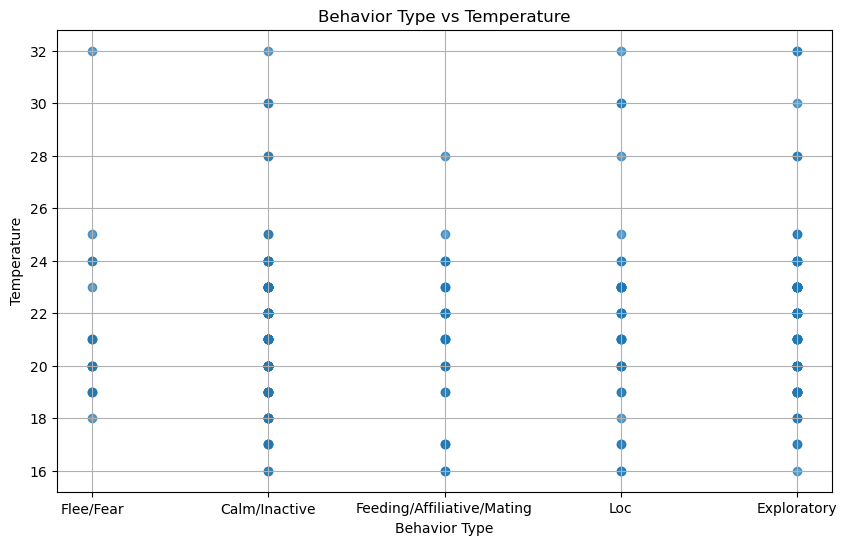

In [16]:

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(transformed_data['behavior_type'], transformed_data['Temperature'], alpha=0.7)

plt.title('Behavior Type vs Temperature')
plt.xlabel('Behavior Type')
plt.ylabel('Temperature')
plt.grid(True)

plt.show()


## Behavioral states vs wind 

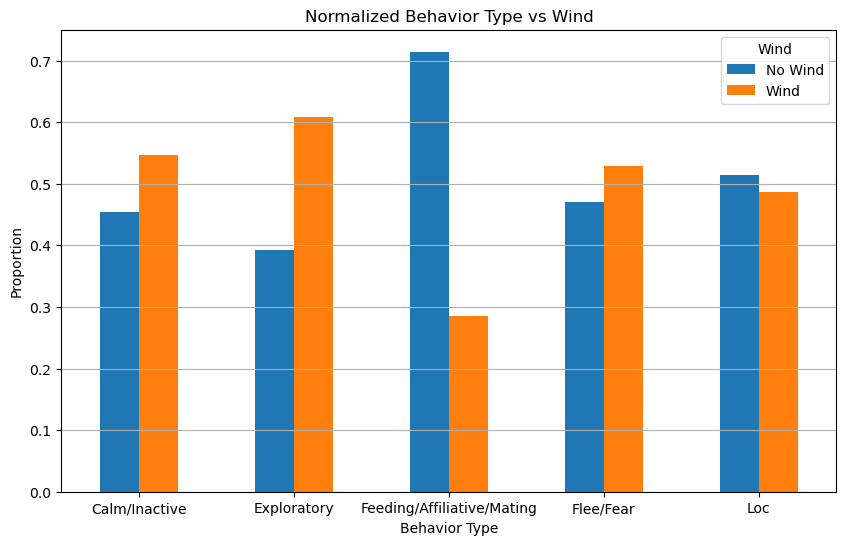

In [17]:
# Grouping and normalizing the data
wind_counts = transformed_data.groupby(['behavior_type', 'Wind']).size().unstack(fill_value=0)
wind_proportions = wind_counts.div(wind_counts.sum(axis=1), axis=0)

# Plotting
wind_proportions.plot(kind='bar', stacked=False, figsize=(10, 6))

plt.title('Normalized Behavior Type vs Wind')
plt.xlabel('Behavior Type')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['No Wind', 'Wind'], title='Wind')
plt.grid(axis='y')

plt.show()

## Behavioral states before and during flight

         Date  Week
0  2024-11-07    45
1  2024-11-07    45
2  2024-11-07    45
3  2024-11-08    45
4  2024-11-08    45
..        ...   ...
64 2024-11-23    47
65 2024-11-25    48
66 2024-11-25    48
67 2024-11-25    48
68 2024-11-25    48

[69 rows x 2 columns]
    BF_Flee/Fear  BF_Calm/Inactive  BF_Feeding/Affiliative/Mating  \
0            0.0                 1                              0   
1            0.0                 1                              0   
2            0.0                 1                              0   
3            0.0                 1                              0   
4            0.0                 1                              0   
..           ...               ...                            ...   
64           0.0                 1                              0   
65           0.0                 1                              0   
66           0.0                 1                              0   
67           0.0                 1             

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_49402/3400951725.py:36: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))


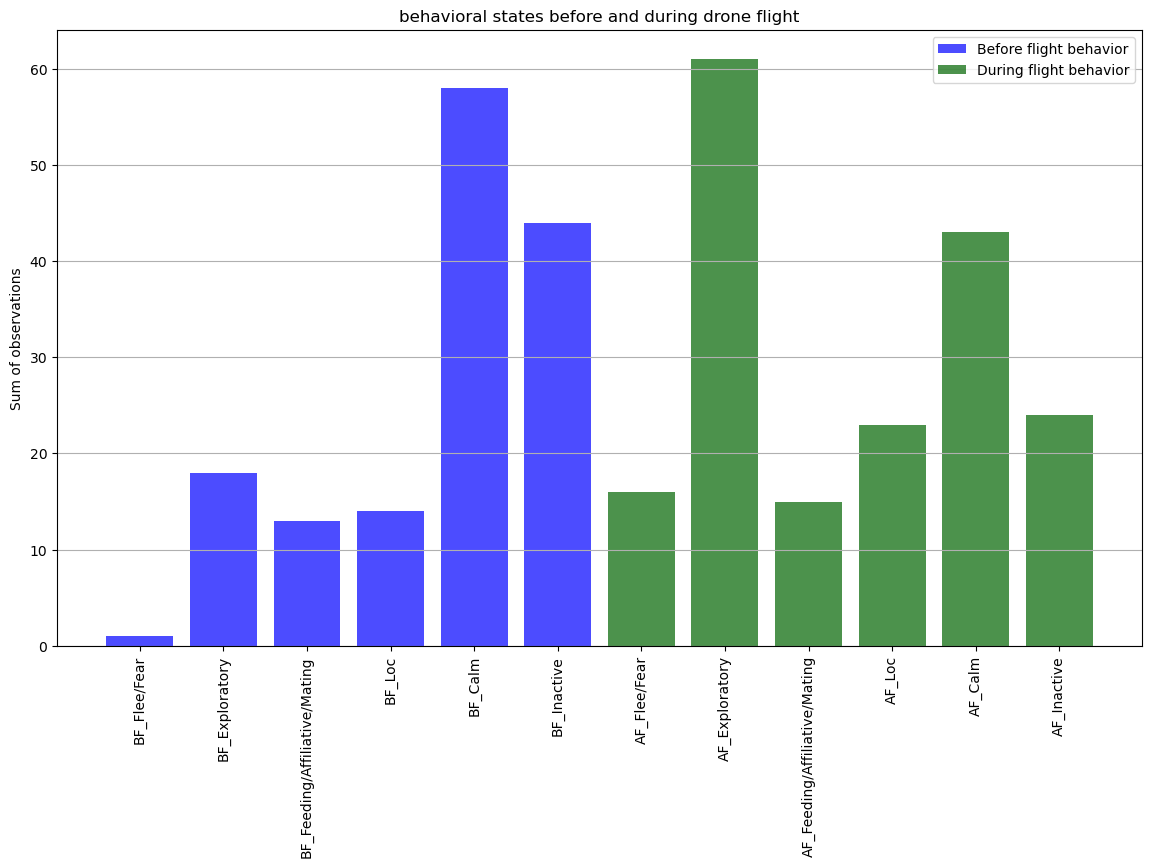

Sum of each BF behavior:
BF_Flee/Fear                      1
BF_Exploratory                   18
BF_Feeding/Affiliative/Mating    13
BF_Loc                           14
BF_Calm                          58
BF_Inactive                      44

Sum of each AF behavior:
AF_Flee/Fear                     16
AF_Exploratory                   61
AF_Feeding/Affiliative/Mating    15
AF_Loc                           23
AF_Calm                          43
AF_Inactive                      24


In [3]:



data = df[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Agonistic', 'BF_Aggressive/Flee', 'BF_Fear', 'BF_Stereotypic', 
'BF_Vocalization', 'BF_Active/Exploratory', 'BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Affiliative_Reproductive', 
'BF_Loc', 'BF_Calm', 'BF_Inactive', 'AF_Agonistic', 'AF_Aggressive/Flee', 'AF_Fear', 'AF_Stereotypic', 'AF_Vocalization', 
'AF_Active/Exploratory', 'AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 
'AF_Calm', 'AF_Inactive', 'Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'prides', 'Temperature', 'Wind']]

data = data.rename(columns={'BF_Aggressive/Flee': 'BF_Flee'})  
data = data.rename(columns={'AF_Aggressive/Flee': 'AF_Flee'})  
data = data.rename(columns={'BF_Active/Exploratory': 'BF_Exploratory'})  
data = data.rename(columns={'AF_Active/Exploratory': 'AF_Exploratory'})  
data = data[data['Species'] == 'Lion']

data['Pride_ID'] = data['Test_ID'].str[:2]

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract the week number and create a new 'Week' column
data['Week'] = data['Date'].dt.isocalendar().week

# Display the resulting DataFrame with the new 'Week' column
print(data[['Date', 'Week']])

columns_to_transform = [
    'BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic', 
    'BF_Vocalization', 'BF_Exploratory', 'BF_Marking', 'BF_Maintenance', 
    'BF_Feeding', 'BF_Affiliative_Reproductive', 'BF_Loc', 'BF_Calm', 
    'BF_Inactive', 'AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic', 
    'AF_Vocalization', 'AF_Exploratory', 'AF_Marking', 'AF_Maintenance', 
    'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 'AF_Calm', 
    'AF_Inactive',  'Kill', 'Pride_with_cubs'
]

# Transform the values
data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))

# Define a function to convert positive sums to 1
def convert_to_binary(value):
    return 1 if value > 0 else value


# Combine columns as specified and apply the conversion function
data['BF_Flee/Fear'] = data[['BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['BF_Calm/Inactive'] = data[['BF_Calm', 'BF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['BF_Feeding/Affiliative/Mating'] = data[['BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Vocalization', 'BF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)
data['AF_Flee/Fear'] = data[['AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['AF_Calm/Inactive'] = data[['AF_Calm', 'AF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['AF_Feeding/Affiliative/Mating'] = data[['AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Vocalization', 'AF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)

# Display the resulting DataFrame
print(data[['BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating']])

# --- Altitude Transformation ---
data['log_altitude'] = np.log(data['Altitude'])
data['z_log_altitude'] = (data['log_altitude'] - data['log_altitude'].mean()) / data['log_altitude'].std()

data = data[['Test_ID', 'BF_Calm', 'BF_Inactive','AF_Calm', 'AF_Inactive','Date', 'Species', 'Altitude', 'BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 'BF_Loc', 'BF_Exploratory',
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating', 'AF_Loc', 'AF_Exploratory','Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'log_altitude', 'z_log_altitude', 'prides', 'Temperature', 'Wind']]


new_columns = [
    'BF_Flee/Fear', 
     'BF_Exploratory', 'BF_Feeding/Affiliative/Mating', 'BF_Loc', 'BF_Calm', 
    'BF_Inactive', 'AF_Flee/Fear', 
    'AF_Exploratory', 'AF_Feeding/Affiliative/Mating', 'AF_Loc', 'AF_Calm', 
    'AF_Inactive'
]


# Split the data into two datasets
bf_columns = [col for col in new_columns if col.startswith('BF')]
af_columns = [col for col in new_columns if col.startswith('AF')]

bf_data = data[bf_columns]
af_data = data[af_columns]

# Calculate the sum of 1s for each column in both datasets
sums_of_ones_bf = {column: (bf_data[column] == 1).sum() for column in bf_columns}
sums_of_ones_af = {column: (af_data[column] == 1).sum() for column in af_columns}

# Filter columns where there is at least one '1'
filtered_columns_bf = {column: sum_ones for column, sum_ones in sums_of_ones_bf.items() if sum_ones > 0}
filtered_columns_af = {column: sum_ones for column, sum_ones in sums_of_ones_af.items() if sum_ones > 0}

# Plot 
plt.figure(figsize=(14, 8))

plt.bar(filtered_columns_bf.keys(), filtered_columns_bf.values(), color='blue', alpha=0.7, label='Before flight behavior')

plt.bar(filtered_columns_af.keys(), filtered_columns_af.values(), color='darkgreen', alpha=0.7, label='During flight behavior')

plt.title('behavioral states before and during drone flight')
plt.ylabel('Sum of observations')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.legend()
plt.savefig('behav.states.before.and.during.flight.png', bbox_inches='tight')
plt.show()

# Print the sum of each behavior for BF and AF
bf_sums = bf_data.fillna(0).astype(int).sum()
af_sums = af_data.fillna(0).astype(int).sum()

print("Sum of each BF behavior:")
print(bf_sums.to_string())

print("\nSum of each AF behavior:")
print(af_sums.to_string())

# Save the plot as a PNG file
#plt.savefig('my_plot.png')

# Save the plot as a PDF file
# plt.savefig('my_plot.pdf')

NameError: name 'textwrap' is not defined

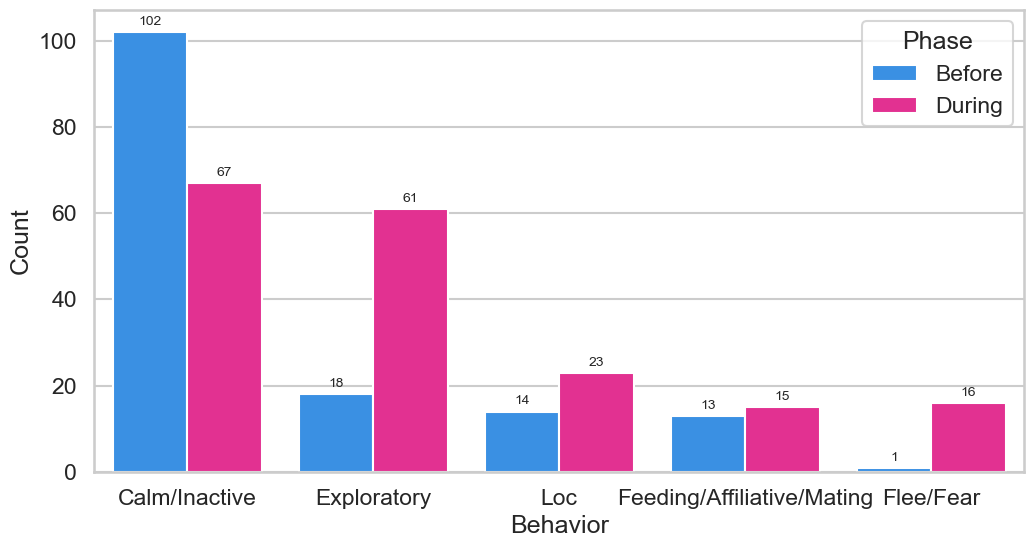

In [22]:

# Split columns by phase
bf_columns = [col for col in new_columns if col.startswith('BF_')]
af_columns = [col for col in new_columns if col.startswith('AF_')]

# Map to merge Calm and Inactive
merge_map = {'Calm': 'Calm/Inactive', 'Inactive': 'Calm/Inactive'}

# Build tidy DataFrame of counts with merged label
records = []
for col in bf_columns:
    beh = col.replace('BF_', '')
    beh = merge_map.get(beh, beh)
    records.append({'Behavior': beh, 'Phase': 'Before', 'Count': (data[col] == 1).sum()})

for col in af_columns:
    beh = col.replace('AF_', '')
    beh = merge_map.get(beh, beh)
    records.append({'Behavior': beh, 'Phase': 'During', 'Count': (data[col] == 1).sum()})

# WARNING: This overwrites the original `data` variable
data = pd.DataFrame(records)

# Sum duplicates created by merging Calm + Inactive
data = data.groupby(['Behavior', 'Phase'], as_index=False)['Count'].sum()

# Keep only behaviors observed at least once in either phase
keep = data.groupby('Behavior')['Count'].sum()
data = data[data['Behavior'].isin(keep[keep > 0].index)]

# Pivot
wide = data.pivot_table(index='Behavior', columns='Phase', values='Count', aggfunc='sum', fill_value=0)
wide = wide.reindex(columns=['Before', 'During'], fill_value=0)  # consistent column order

# Sort behaviors by total observations (descending)
wide['Total'] = wide.sum(axis=1)
wide = wide.sort_values('Total', ascending=False)
behavior_order = wide.index.tolist()

# Melt back to long for seaborn
plot_df = wide.drop(columns='Total').reset_index().melt(id_vars='Behavior', var_name='Phase', value_name='Count')

# Plot
sns.set_theme(style='whitegrid', context='talk')
palette = {'Before': 'dodgerblue', 'During': 'deeppink'}

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_df,
    x='Behavior', y='Count',
    hue='Phase', hue_order=['Before', 'During'],
    order=behavior_order,
    palette=palette
)

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=10)

# Wrap long x labels (e.g., "Feeding/Affiliative/Mating")
wrapped = [textwrap.fill(lbl.get_text(), width=16) for lbl in ax.get_xticklabels()]
ax.set_xticklabels(wrapped, rotation=0)

# Titles and labels
ax.set_title('Behavioral states before and during drone flight', pad=12)
ax.set_xlabel('')
ax.set_ylabel('Number of observations')
ax.legend(title='Phase', frameon=True)

sns.despine()
plt.tight_layout()
plt.savefig('behav_states_before_vs_during_grouped_merged.png', dpi=300, bbox_inches='tight')
plt.show()

## Habituation

### Flee/Fear reactions vs week of the test

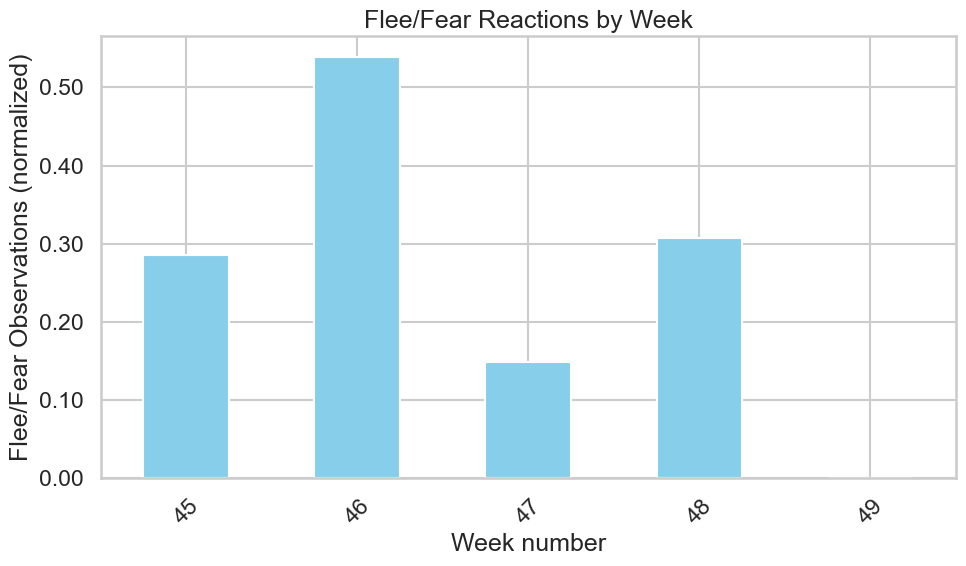

In [27]:
# Calculate the number of observations for each week
observation_counts = data.groupby('Week').size()

grouped_data = data.groupby('Week')['AF_Flee/Fear'].sum()

normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='skyblue')

plt.title('Flee/Fear Reactions by Week')
plt.xlabel('Week number')
plt.ylabel('Flee/Fear Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Exploratory reactions vs week of the test

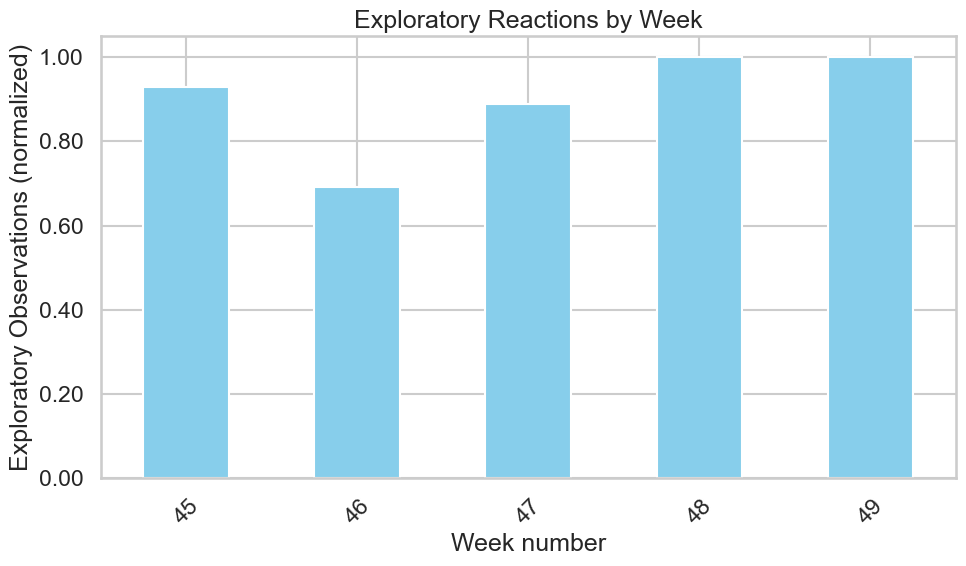

In [28]:
# Calculate the number of observations for each week
observation_counts = data.groupby('Week').size()

grouped_data = data.groupby('Week')['AF_Exploratory'].sum()

normalized_data = grouped_data / observation_counts

# Plot
plt.figure(figsize=(10, 6))
normalized_data.plot(kind='bar', color='skyblue')

plt.title('Exploratory Reactions by Week')
plt.xlabel('Week number')
plt.ylabel('Exploratory Observations (normalized)')

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Behavioral changes depending on Pride ID and Cluster ID

### data preparation

In [29]:
# data manipulation
# CELL01

# data preparation 

file_path = 'ToleranceTest_MasterDoc.xlsx'

df1 = pd.read_excel(file_path, engine='openpyxl')

data = df[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Agonistic', 'BF_Aggressive/Flee', 'BF_Fear', 'BF_Stereotypic', 
'BF_Vocalization', 'BF_Active/Exploratory', 'BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Affiliative_Reproductive', 
'BF_Loc', 'BF_Calm', 'BF_Inactive', 'AF_Agonistic', 'AF_Aggressive/Flee', 'AF_Fear', 'AF_Stereotypic', 'AF_Vocalization', 
'AF_Active/Exploratory', 'AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 
'AF_Calm', 'AF_Inactive', 'Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'prides']]

data = data.rename(columns={'BF_Aggressive/Flee': 'BF_Flee'})  
data = data.rename(columns={'AF_Aggressive/Flee': 'AF_Flee'})  
data = data.rename(columns={'BF_Active/Exploratory': 'BF_Exploratory'})  
data = data.rename(columns={'AF_Active/Exploratory': 'AF_Exploratory'})  
data = data[data['Species'] == 'Lion']


data['Pride_ID'] = data['Test_ID'].str[:2]

# Ensure the 'Date' column is in datetime format
data['Date'] = pd.to_datetime(data['Date'])

# Extract the week number and create a new 'Week' column
data['Week'] = data['Date'].dt.isocalendar().week

# ADD: Cluster_ID as Pride_ID + 'x' + DDMM
data['Cluster_ID'] = data['Pride_ID'].astype(str) + 'x' + data['Date'].dt.strftime('%d%m')

# Display the resulting DataFrame with the new 'Week' column
print(data[['Date', 'Week']])

columns_to_transform = [
    'BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic', 
    'BF_Vocalization', 'BF_Exploratory', 'BF_Marking', 'BF_Maintenance', 
    'BF_Feeding', 'BF_Affiliative_Reproductive', 'BF_Loc', 'BF_Calm', 
    'BF_Inactive', 'AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic', 
    'AF_Vocalization', 'AF_Exploratory', 'AF_Marking', 'AF_Maintenance', 
    'AF_Feeding', 'AF_Affiliative_Reproductive', 'AF_Loc', 'AF_Calm', 
    'AF_Inactive',  'Kill', 'Pride_with_cubs'
]

# Transform the values
data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))

# Define a function to convert positive sums to 1
def convert_to_binary(value):
    return 1 if value > 0 else value

# Combine columns as specified and apply the conversion function
data['BF_Flee/Fear'] = data[['BF_Agonistic', 'BF_Flee', 'BF_Fear', 'BF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['BF_Calm/Inactive'] = data[['BF_Calm', 'BF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['BF_Feeding/Affiliative/Mating'] = data[['BF_Marking', 'BF_Maintenance', 'BF_Feeding', 'BF_Vocalization', 'BF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)
data['AF_Flee/Fear'] = data[['AF_Agonistic', 'AF_Flee', 'AF_Fear', 'AF_Stereotypic']].sum(axis=1).apply(convert_to_binary)
data['AF_Calm/Inactive'] = data[['AF_Calm', 'AF_Inactive']].sum(axis=1).apply(convert_to_binary)
data['AF_Feeding/Affiliative/Mating'] = data[['AF_Marking', 'AF_Maintenance', 'AF_Feeding', 'AF_Vocalization', 'AF_Affiliative_Reproductive']].sum(axis=1).apply(convert_to_binary)

# Display the resulting DataFrame
print(data[['BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating']])

# --- Altitude Transformation ---
data['log_altitude'] = np.log(data['Altitude'])
data['z_log_altitude'] = (data['log_altitude'] - data['log_altitude'].mean()) / data['log_altitude'].std()

data = data[['Test_ID', 'Date', 'Species', 'Altitude', 'BF_Flee/Fear', 'BF_Calm/Inactive','BF_Feeding/Affiliative/Mating', 'BF_Loc', 'BF_Exploratory',
            'AF_Flee/Fear', 'AF_Calm/Inactive', 'AF_Feeding/Affiliative/Mating', 'AF_Loc', 'AF_Exploratory','Kill', 'Pride_with_cubs', 'BF_Distance_averaged', 'Time', 'DroneVIDEO_N_c', 
           'DroneVIDEO_N_M', 'DroneVIDEO_N_F', 'vegetation', 'log_altitude', 'z_log_altitude', 'prides', 'Pride_ID', 'Cluster_ID']]



def melt_behavior_data(data, prefix):
    behavior_columns = [
        f'{prefix}_Flee/Fear', f'{prefix}_Calm/Inactive', f'{prefix}_Feeding/Affiliative/Mating', f'{prefix}_Loc',  f'{prefix}_Exploratory'
    ]
    # Include 'Pride_with_cubs' and 'DroneVIDEO_N_c' in id_vars to retain them
    melted_data = data.melt(
        id_vars=['Test_ID', 'Date', 'Species', 'Altitude','z_log_altitude', 'Pride_with_cubs', 'DroneVIDEO_N_c', 'prides', 'Pride_ID', 'Cluster_ID'],
        value_vars=behavior_columns,
        var_name='behavior_type',
        value_name='behavior_count'
    )
    melted_data['before_after'] = 0 if prefix == 'BF' else 1
    melted_data['behavior_type'] = melted_data['behavior_type'].str.replace(f'{prefix}_', '')
    return melted_data[melted_data['behavior_count'] > 0]

# Melt the data for 'before' and 'after'
before_data = melt_behavior_data(data, 'BF')
after_data = melt_behavior_data(data, 'AF')

# Concatenate the melted data
transformed_data = pd.concat([before_data, after_data], ignore_index=True)

# Use z_log_altitude only for 'after' observations
transformed_data.loc[transformed_data['before_after'] == 0, 'z_log_altitude'] = np.nan
transformed_data['z_log_altitude'].fillna(0, inplace=True)

# Select relevant columns
transformed_data = transformed_data[['Test_ID', 'Date', 'Species', 'Altitude', 'before_after', 'behavior_type', 'z_log_altitude', 'Pride_with_cubs', 'DroneVIDEO_N_c', 'prides','Pride_ID', 'Cluster_ID']]

# Create a categorical column 'Cubs_presence' where:
# 0=pride has no cubs, 1=pride has cubs but they're not present during the test, 2=pride has cubs and they're present during the test

# Create the new column with priority logic
transformed_data["Cubs_presence"] = np.where(transformed_data["DroneVIDEO_N_c"] != 0, 2, transformed_data["Pride_with_cubs"])

# Delete extra columns
transformed_data = transformed_data.drop(["DroneVIDEO_N_c"], axis=1)

         Date  Week
0  2024-11-07    45
1  2024-11-07    45
2  2024-11-07    45
3  2024-11-08    45
4  2024-11-08    45
..        ...   ...
64 2024-11-23    47
65 2024-11-25    48
66 2024-11-25    48
67 2024-11-25    48
68 2024-11-25    48

[69 rows x 2 columns]
    BF_Flee/Fear  BF_Calm/Inactive  BF_Feeding/Affiliative/Mating  \
0            0.0                 1                              0   
1            0.0                 1                              0   
2            0.0                 1                              0   
3            0.0                 1                              0   
4            0.0                 1                              0   
..           ...               ...                            ...   
64           0.0                 1                              0   
65           0.0                 1                              0   
66           0.0                 1                              0   
67           0.0                 1             

/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_3838/1381583988.py:49: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  data[columns_to_transform] = data[columns_to_transform].applymap(lambda x: 1 if x == 'Y' else (0 if x == 'N' else x))
/var/folders/g5/lfnych997zb4kwtv4s8q1s8w0000gn/T/ipykernel_3838/1381583988.py:101: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transformed_data['z_log_altitude'].fillna(0, inplace=True)


### Flee/Fear x Pride ID and Cluster ID

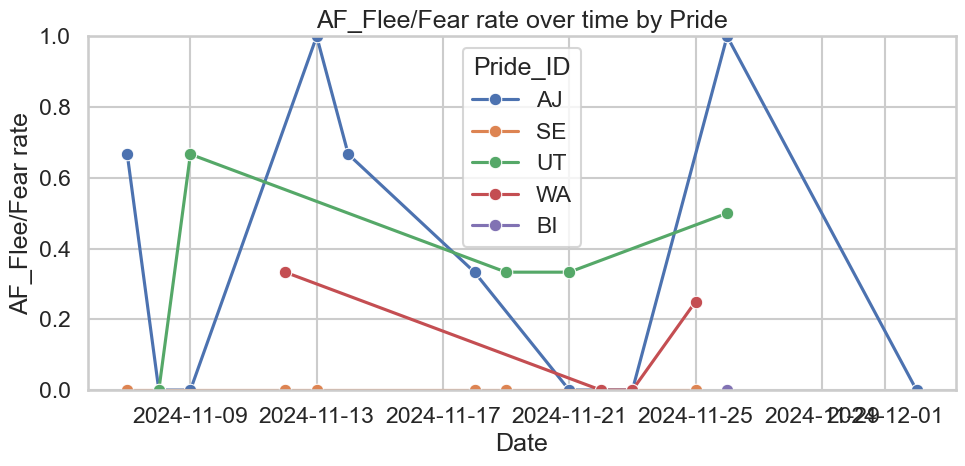

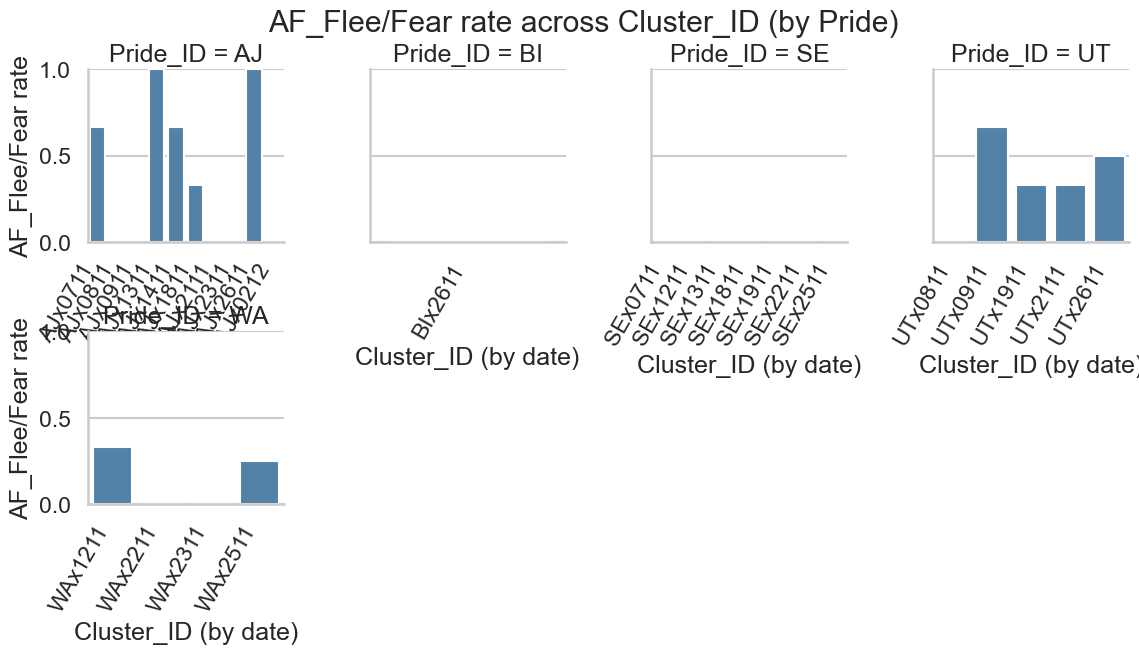

In [30]:
# 1) Aggregate AF_Flee/Fear rate per Cluster_ID (per Pride and Date)
af_cluster = (
    data
    .groupby(['Pride_ID', 'Cluster_ID', 'Date'], as_index=False)
    .agg(af_flee_fear_rate=('AF_Flee/Fear', 'mean'),
         n_tests=('AF_Flee/Fear', 'size'))
    .sort_values('Date')
)

# 2A) Time-trend line plot (x = Date)
plt.figure(figsize=(10, 5))
sns.lineplot(data=af_cluster, x='Date', y='af_flee_fear_rate', hue='Pride_ID', marker='o')
plt.title('AF_Flee/Fear rate over time by Pride')
plt.ylabel('AF_Flee/Fear rate')
plt.xlabel('Date')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 2B) Faceted bar plot by Pride with Cluster_ID on x-axis (ordered by Date)
# Create an ordered categorical for Cluster_ID within each Pride by Date
af_cluster = af_cluster.sort_values(['Pride_ID', 'Date'])
af_cluster['Cluster_ID_ordered'] = af_cluster.groupby('Pride_ID')['Cluster_ID'] \
    .transform(lambda x: pd.Categorical(x, categories=x, ordered=True))

g = sns.FacetGrid(af_cluster, col='Pride_ID', col_wrap=4, sharex=False, sharey=True, height=3)
g.map_dataframe(sns.barplot, x='Cluster_ID_ordered', y='af_flee_fear_rate', color='steelblue')
g.set_axis_labels('Cluster_ID (by date)', 'AF_Flee/Fear rate')
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(60)
        label.set_ha('right')
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle('AF_Flee/Fear rate across Cluster_ID (by Pride)')
plt.ylim(0, 1)
plt.show()

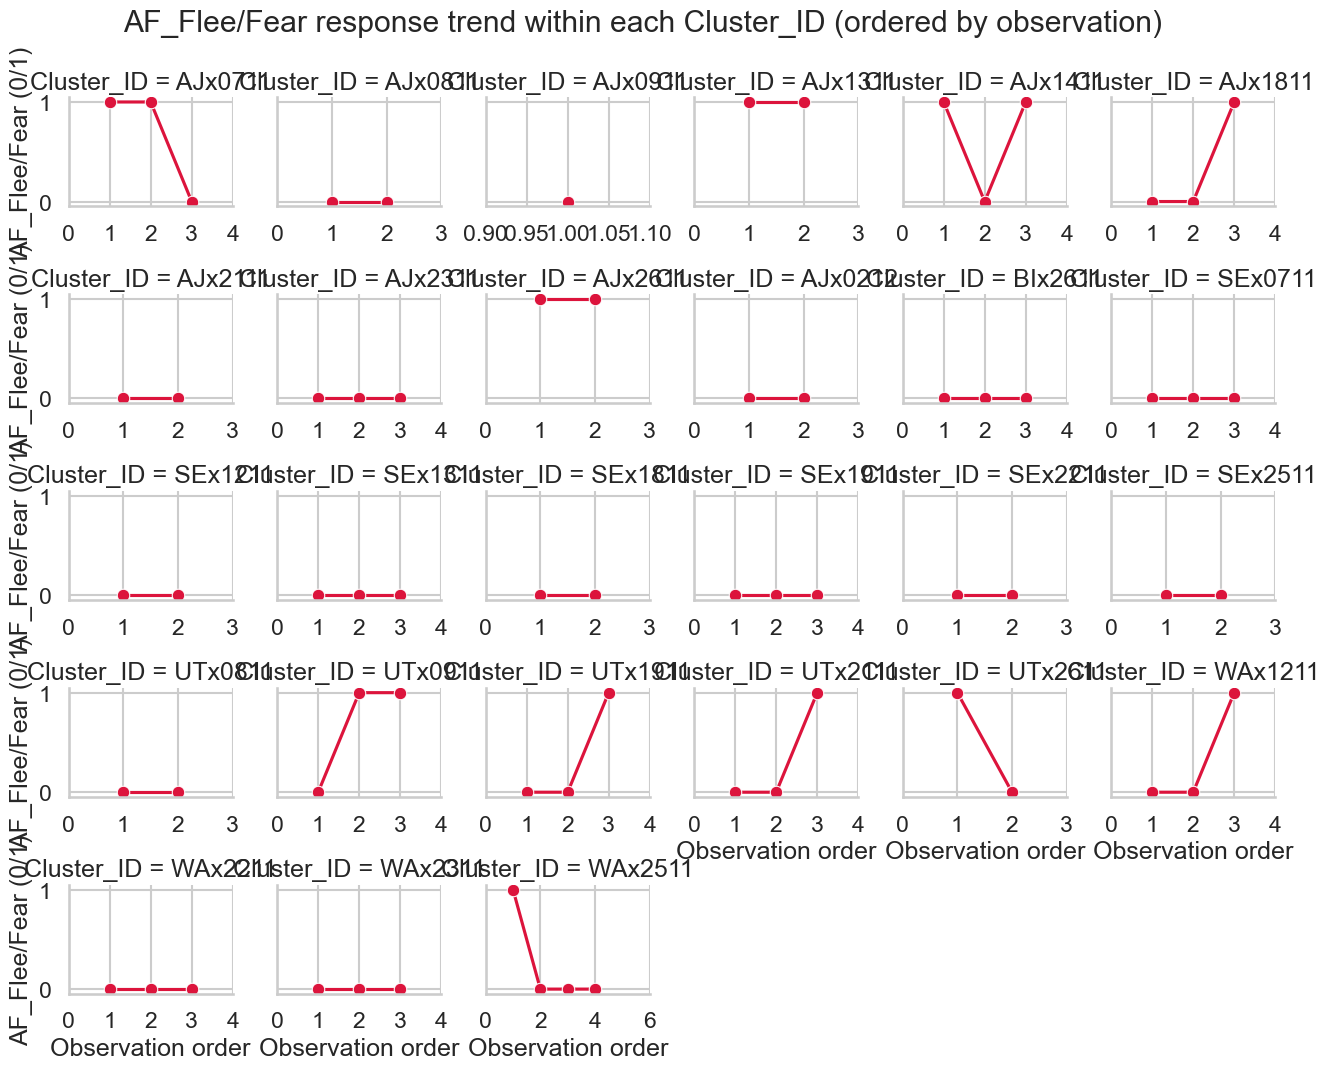

In [31]:
# Per Cluster ID
# Build per-observation order within each Cluster_ID
plot_cols = ['Pride_ID', 'Cluster_ID', 'Date', 'Time', 'Test_ID', 'AF_Flee/Fear']
data_plot = data[plot_cols].copy()

# Try to use Time to order within the day; fallback to Test_ID/index if Time is unusable
# If Time is already numeric, keep it; else try to parse; else fallback
if 'Time' in data_plot.columns:
    if not np.issubdtype(data_plot['Time'].dtype, np.number):
        data_plot['Time_dt'] = pd.to_datetime(data_plot['Time'], errors='coerce')
    else:
        data_plot['Time_dt'] = data_plot['Time']
else:
    data_plot['Time_dt'] = pd.NaT

# Sort with robust fallbacks
if data_plot['Time_dt'].isna().all():
    data_plot = data_plot.sort_values(['Pride_ID', 'Cluster_ID', 'Date', 'Test_ID']).copy()
else:
    data_plot = data_plot.sort_values(['Pride_ID', 'Cluster_ID', 'Date', 'Time_dt', 'Test_ID']).copy()

# Observation sequence within each Cluster_ID (1-based)
data_plot['obs_order'] = data_plot.groupby('Cluster_ID').cumcount() + 1

# Optional: order clusters by pride and earliest date for nicer faceting
cluster_order = (
    data_plot.groupby('Cluster_ID', as_index=False)
    .agg(Pride_ID=('Pride_ID', 'first'), start=('Date', 'min'))
    .sort_values(['Pride_ID', 'start'])['Cluster_ID']
)
data_plot['Cluster_ID'] = pd.Categorical(data_plot['Cluster_ID'],
                                         categories=cluster_order,
                                         ordered=True)

# Plot: AF_Flee/Fear trend within each Cluster_ID by observation order
g = sns.FacetGrid(data_plot, col='Cluster_ID', col_wrap=6, sharex=False, sharey=True, height=2.2)
g.map_dataframe(sns.lineplot, x='obs_order', y='AF_Flee/Fear', marker='o', color='crimson')
g.set_axis_labels('Observation order', 'AF_Flee/Fear (0/1)')
for ax in g.axes.flatten():
    ax.set_ylim(-0.05, 1.05)
    ax.set_xticks(sorted(ax.get_xticks()))
g.fig.subplots_adjust(top=0.90)
g.fig.suptitle('AF_Flee/Fear response trend within each Cluster_ID (ordered by observation)')
plt.show()

### Clam/Inactive x Pride ID and Cluster ID

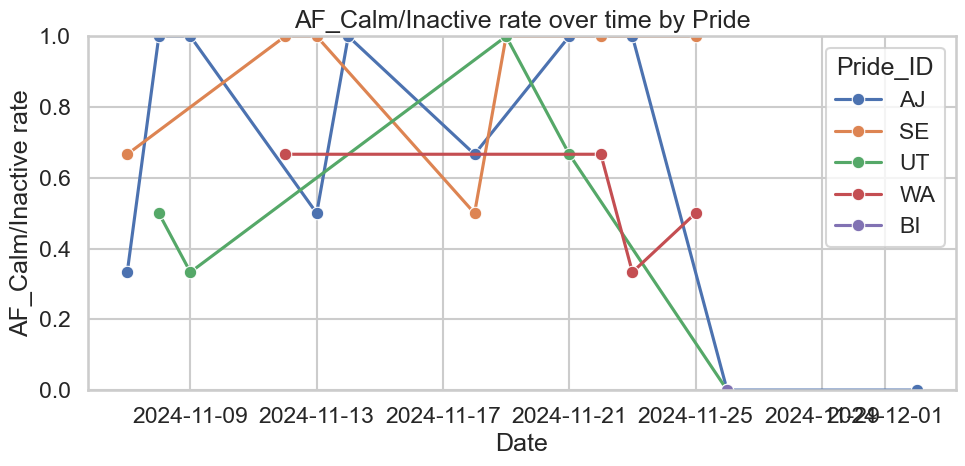

In [32]:
# 1) Aggregate AF_Calm/Inactive rate per Cluster_ID (per Pride and Date)
af_cluster = (
    data
    .groupby(['Pride_ID', 'Cluster_ID', 'Date'], as_index=False)
    .agg(af_flee_fear_rate=('AF_Calm/Inactive', 'mean'),
         n_tests=('AF_Calm/Inactive', 'size'))
    .sort_values('Date')
)

# 2A) Time-trend line plot (x = Date)
plt.figure(figsize=(10, 5))
sns.lineplot(data=af_cluster, x='Date', y='af_flee_fear_rate', hue='Pride_ID', marker='o')
plt.title('AF_Calm/Inactive rate over time by Pride')
plt.ylabel('AF_Calm/Inactive rate')
plt.xlabel('Date')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


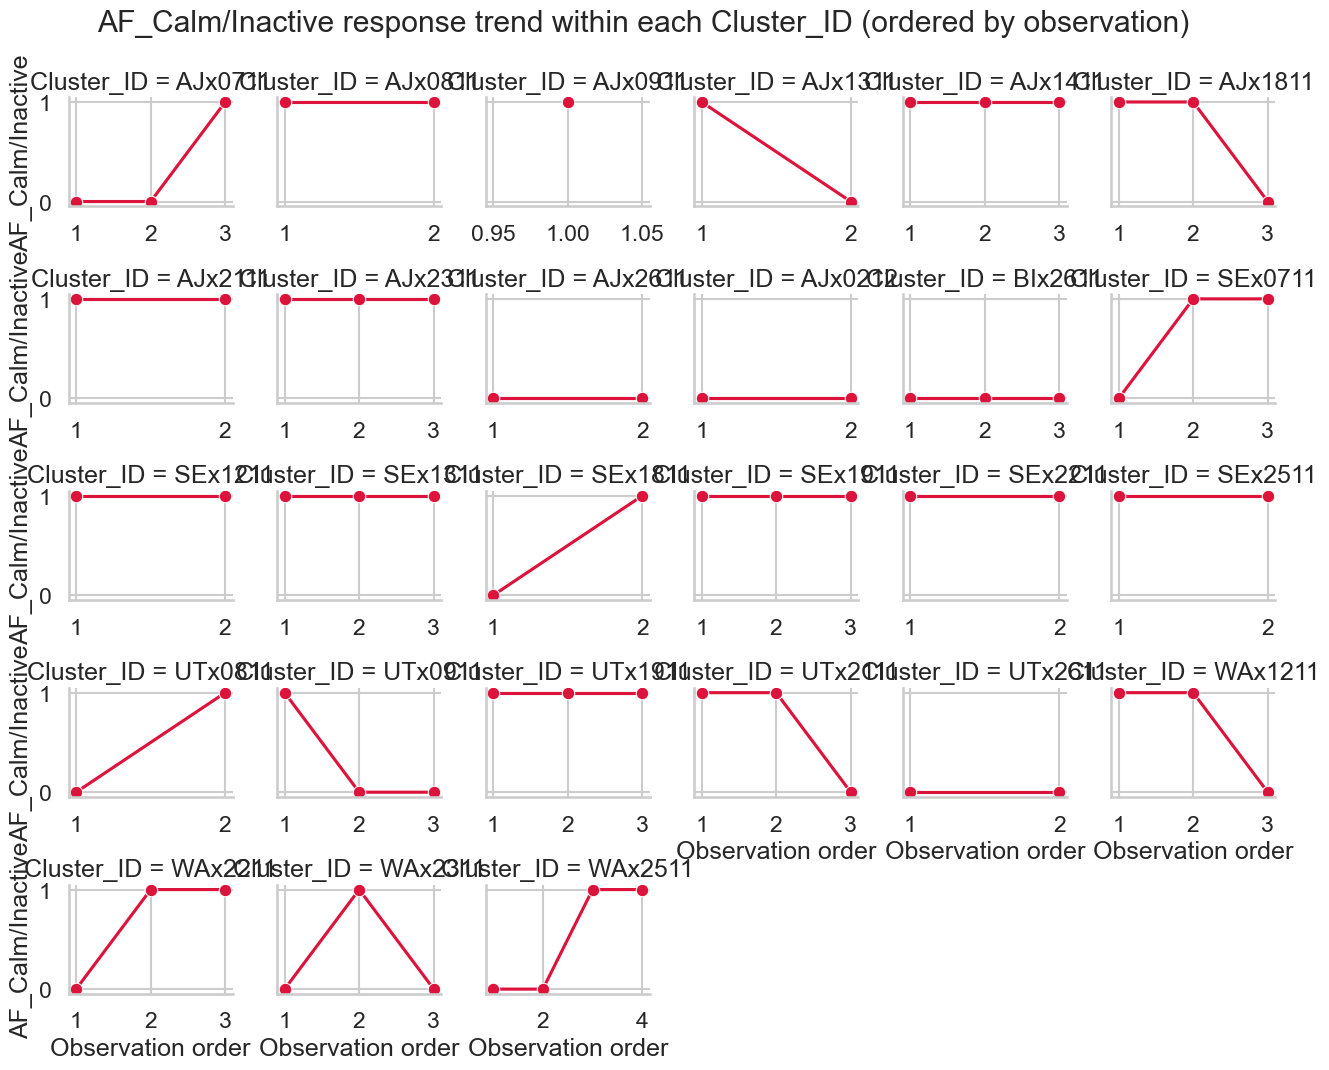

In [33]:
# Cluster ID
def plot_cluster_trend(data, value_col, col_wrap=6, height=2.2):
    # Prepare data with ordering within Cluster_ID
    plot_cols = ['Pride_ID', 'Cluster_ID', 'Date', 'Time', 'Test_ID', value_col]
    df = data[plot_cols].copy()

    # Parse/handle Time for ordering
    if 'Time' in df.columns:
        if not np.issubdtype(df['Time'].dtype, np.number):
            df['Time_dt'] = pd.to_datetime(df['Time'], errors='coerce')
        else:
            df['Time_dt'] = df['Time']
    else:
        df['Time_dt'] = pd.NaT

    # Robust sort (fallback if Time unusable)
    if df['Time_dt'].isna().all():
        df = df.sort_values(['Pride_ID', 'Cluster_ID', 'Date', 'Test_ID']).copy()
    else:
        df = df.sort_values(['Pride_ID', 'Cluster_ID', 'Date', 'Time_dt', 'Test_ID']).copy()

    # Observation order within each Cluster_ID
    df['obs_order'] = df.groupby('Cluster_ID').cumcount() + 1

    # Optional: order clusters by pride and earliest date
    cluster_order = (
        df.groupby('Cluster_ID', as_index=False)
          .agg(Pride_ID=('Pride_ID', 'first'), start=('Date', 'min'))
          .sort_values(['Pride_ID', 'start'])['Cluster_ID']
    )
    df['Cluster_ID'] = pd.Categorical(df['Cluster_ID'], categories=cluster_order, ordered=True)

    # Plot
    g = sns.FacetGrid(df, col='Cluster_ID', col_wrap=col_wrap, sharex=False, sharey=True, height=height)
    g.map_dataframe(sns.lineplot, x='obs_order', y=value_col, marker='o', color='crimson')
    g.set_axis_labels('Observation order', value_col)
    for ax in g.axes.flatten():
        ax.set_ylim(-0.05, 1.05)  # assumes 0/1; adjust if needed
    g.fig.subplots_adjust(top=0.90)
    g.fig.suptitle(f'{value_col} response trend within each Cluster_ID (ordered by observation)')
    plt.show()

# 1) AF_Calm/Inactive
plot_cluster_trend(data, 'AF_Calm/Inactive', col_wrap=6, height=2.2)



### Exploratory x Pride ID and Cluster ID

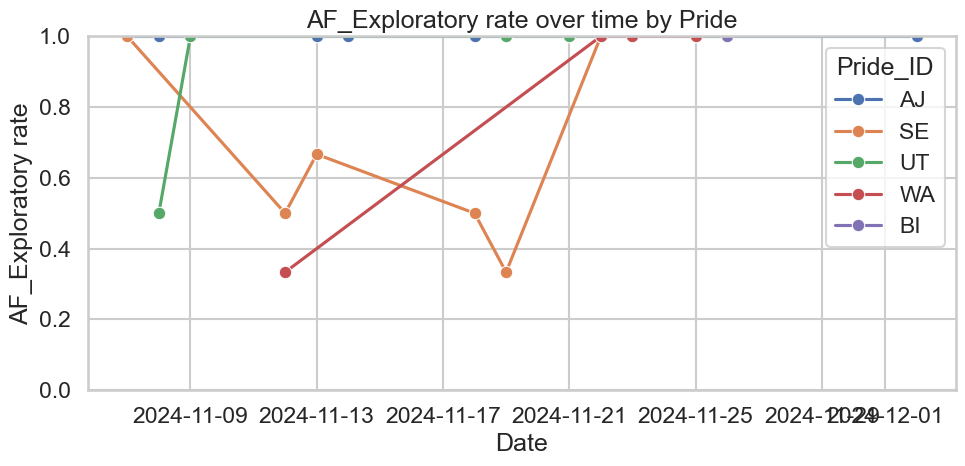

In [34]:
# 1) Aggregate AF_Exploratory rate per Cluster_ID (per Pride and Date)
af_cluster = (
    data
    .groupby(['Pride_ID', 'Cluster_ID', 'Date'], as_index=False)
    .agg(af_flee_fear_rate=('AF_Exploratory', 'mean'),
         n_tests=('AF_Exploratory', 'size'))
    .sort_values('Date')
)

# 2A) Time-trend line plot (x = Date)
plt.figure(figsize=(10, 5))
sns.lineplot(data=af_cluster, x='Date', y='af_flee_fear_rate', hue='Pride_ID', marker='o')
plt.title('AF_Exploratory rate over time by Pride')
plt.ylabel('AF_Exploratory rate')
plt.xlabel('Date')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

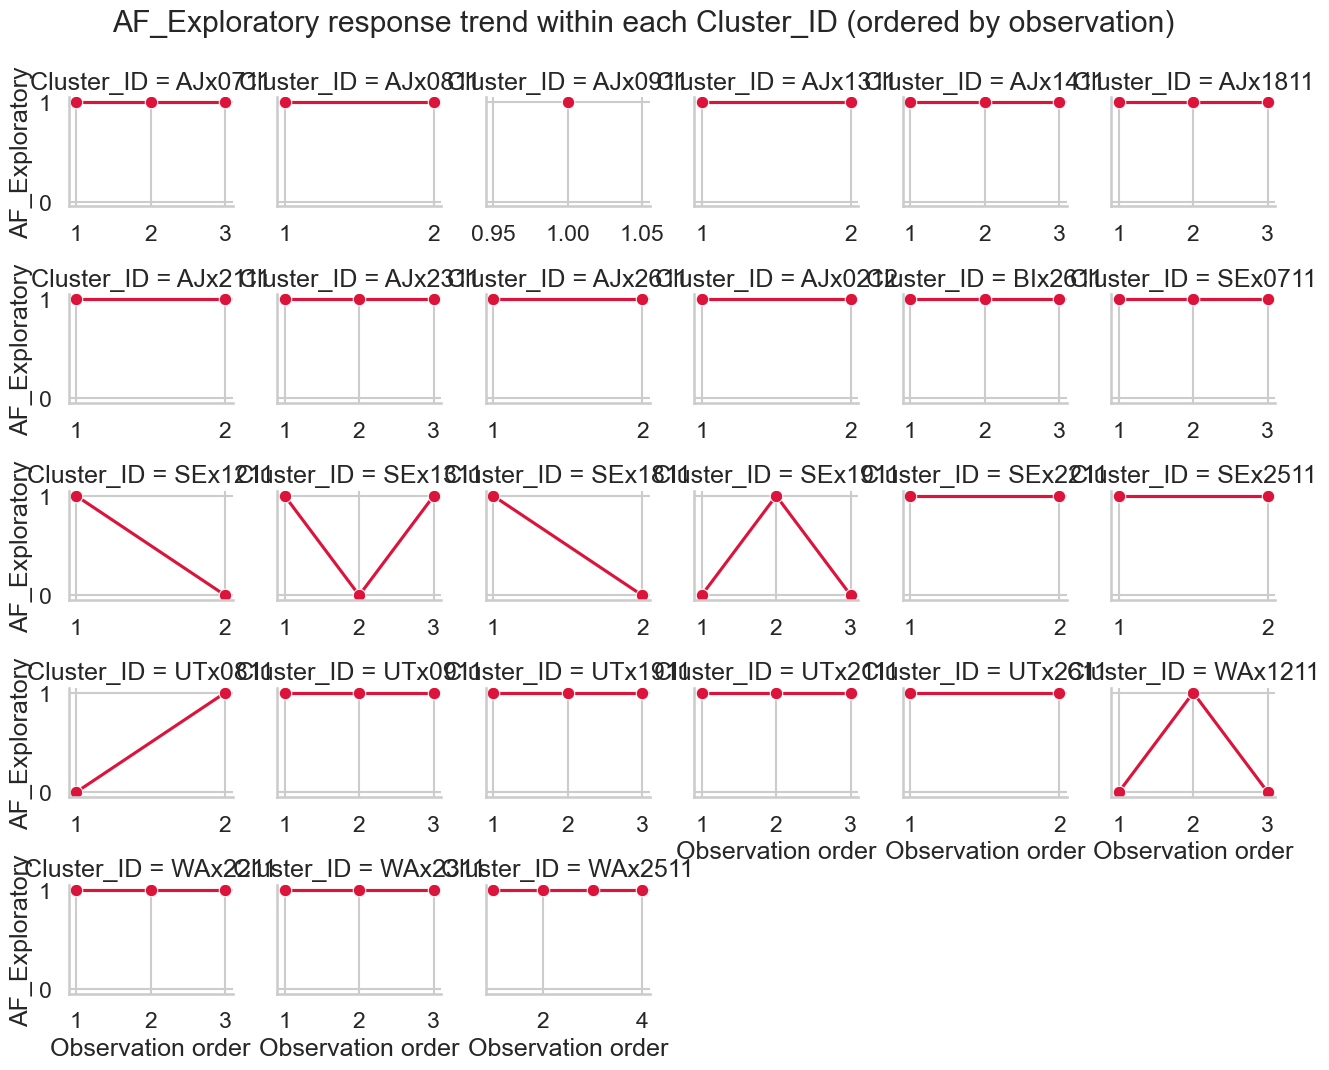

In [35]:
# Cluster ID 
def plot_cluster_trend(data, value_col, col_wrap=6, height=2.2):
    # Prepare data with ordering within Cluster_ID
    plot_cols = ['Pride_ID', 'Cluster_ID', 'Date', 'Time', 'Test_ID', value_col]
    df = data[plot_cols].copy()

    # Parse/handle Time for ordering
    if 'Time' in df.columns:
        if not np.issubdtype(df['Time'].dtype, np.number):
            df['Time_dt'] = pd.to_datetime(df['Time'], errors='coerce')
        else:
            df['Time_dt'] = df['Time']
    else:
        df['Time_dt'] = pd.NaT

    # Robust sort (fallback if Time unusable)
    if df['Time_dt'].isna().all():
        df = df.sort_values(['Pride_ID', 'Cluster_ID', 'Date', 'Test_ID']).copy()
    else:
        df = df.sort_values(['Pride_ID', 'Cluster_ID', 'Date', 'Time_dt', 'Test_ID']).copy()

    # Observation order within each Cluster_ID
    df['obs_order'] = df.groupby('Cluster_ID').cumcount() + 1

    # Optional: order clusters by pride and earliest date
    cluster_order = (
        df.groupby('Cluster_ID', as_index=False)
          .agg(Pride_ID=('Pride_ID', 'first'), start=('Date', 'min'))
          .sort_values(['Pride_ID', 'start'])['Cluster_ID']
    )
    df['Cluster_ID'] = pd.Categorical(df['Cluster_ID'], categories=cluster_order, ordered=True)

    # Plot
    g = sns.FacetGrid(df, col='Cluster_ID', col_wrap=col_wrap, sharex=False, sharey=True, height=height)
    g.map_dataframe(sns.lineplot, x='obs_order', y=value_col, marker='o', color='crimson')
    g.set_axis_labels('Observation order', value_col)
    for ax in g.axes.flatten():
        ax.set_ylim(-0.05, 1.05)  # assumes 0/1; adjust if needed
    g.fig.subplots_adjust(top=0.90)
    g.fig.suptitle(f'{value_col} response trend within each Cluster_ID (ordered by observation)')
    plt.show()
    
# 2) AF_Exploratory
plot_cluster_trend(data, 'AF_Exploratory', col_wrap=6, height=2.2)